# 12 — BCHH rotation, polarization, and spectrogram overview

This notebook prepares the canonical BCHH three-component seismic products. It validates and isolates the seismic channels, rotates them to geographic Z/N/E and source-relative Z/R/T coordinates, computes broad and multiband covariance/TwistPy polarization attributes, and generates event-context figures and Z/R/T spectrograms.

All event origins are the source times in `config.SOURCE_EVENT_TIMES`. Predicted ground-coupled-airwave arrivals at the BCHH array reference are calculated from the configured source–receiver geometry and the Notebook 03 meteorological effective sound speed (approximately 351 m s⁻¹). The approximately 352 m s⁻¹ trace velocity measured across the infrasound array in Notebook 08 is a differential empirical measurement and is not substituted for source-to-receiver propagation here.

This notebook does **not** pick or classify direct P, S, or surface waves and does not calculate direct-wave velocities. Those tasks are isolated in `12b_search_for_direct_seismic_waves.ipynb`, which consumes the unfiltered Z/R/T Stream written here.


## 1. Imports, project paths, and authoritative inputs


In [1]:
from __future__ import annotations

import json
import pickle
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import Normalize
import numpy as np
import pandas as pd
from obspy import Stream, Trace, UTCDateTime, read, read_inventory
from obspy.signal.rotate import rotate_ne_rt

from scipy.signal import spectrogram

try:
    from twistpy.polarization import TimeDomainAnalysis3C
except ImportError as exc:
    raise ImportError(
        "TwistPy is required for Notebook 12. Install it in this kernel with "
        "`python -m pip install twistpy`."
    ) from exc

project_root = Path.cwd().resolve()
if project_root.name == "notebooks":
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from modules import project_config as config

ANALYSIS_CONFIG_FILE = config.NB010_DIR / "analysis_configuration.json"
WEATHER_SUMMARY_FILE = config.NB020_DIR / "weather_acoustic_summary.csv"
if not ANALYSIS_CONFIG_FILE.exists():
    raise FileNotFoundError(
        f"Run 010_prepare_analysis_inputs.ipynb first: {ANALYSIS_CONFIG_FILE}"
    )

analysis_config = json.loads(ANALYSIS_CONFIG_FILE.read_text())

if not WEATHER_SUMMARY_FILE.exists():
    raise FileNotFoundError(
        f"Run 020_analyze_ksc_weather.ipynb first: {WEATHER_SUMMARY_FILE}"
    )
weather_summary = pd.read_csv(WEATHER_SUMMARY_FILE).iloc[0]

GEOMETRY_FILE = Path(analysis_config["geometry_file"]).expanduser()
SOURCE_STREAM_FILE = Path(
    analysis_config["baseline_removed_streams"]["pickle"]
).expanduser()
STATIONXML_FILE = Path(
    analysis_config["notebook_01_products"]["calibrated_stationxml"]
).expanduser()

for label, path in {
    "BCHH geometry": GEOMETRY_FILE,
    "corrected waveform Stream": SOURCE_STREAM_FILE,
    "calibrated StationXML": STATIONXML_FILE,
}.items():
    if not path.exists():
        raise FileNotFoundError(f"Missing {label}: {path}")

OUTPUT_ROOT = config.NB130_DIR
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
config.NB130_DIR.mkdir(parents=True, exist_ok=True)

POLARIZATION_CSV = OUTPUT_ROOT / "polarization_timeseries.csv"
POLARIZATION_NPZ = OUTPUT_ROOT / "polarization_timeseries.npz"
ROTATED_ZNE_PICKLE = OUTPUT_ROOT / "seismic_zne.pkl"
ROTATED_ZRT_PICKLE = OUTPUT_ROOT / "seismic_zrt.pkl"
SUMMARY_JSON = OUTPUT_ROOT / "polarization_summary.json"
TWISTPY_ZNE_FIGURE = config.NB130_DIR / "twistpy_style_zne.pdf"
TWISTPY_ZRT_FIGURE = config.NB130_DIR / "twistpy_style_zrt.pdf"
MULTIBAND_OUTPUT_DIR = OUTPUT_ROOT / "multiband"
MULTIBAND_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MULTIBAND_TABLE = MULTIBAND_OUTPUT_DIR / "multiband_polarization_timeseries.csv"
MULTIBAND_COMPARISON_FIGURE = config.NB130_DIR / "multiband_polarization_comparison.pdf"
SPECTROGRAM_FIGURES = []

print("Waveform source:", SOURCE_STREAM_FILE)
print("Weather summary:", WEATHER_SUMMARY_FILE)
print("Geometry:", GEOMETRY_FILE)
print("StationXML:", STATIONXML_FILE)
print("Output directory:", OUTPUT_ROOT)


Waveform source: /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/010_prepare_analysis_inputs/bchh_corrected_moving_median_baseline_removed.pkl
Weather summary: /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/020_analyze_ksc_weather/weather_acoustic_summary.csv
Geometry: /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/010_prepare_analysis_inputs/bchh_channels.csv
StationXML: /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/000_correct_bchh_instrument_response/BCHH_20160901_empirically_calibrated.xml
Output directory: /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/130_analyze_seismic_polarization


## 2. Analysis controls


In [2]:
# -----------------------------------------------------------------------------
# Authoritative source times and common event interval
# -----------------------------------------------------------------------------
required_source_event_keys = (
    "upper_stage",
    "lower_stage",
    "capsule_impact",
    "capsule_explosion",
)
missing_source_event_keys = [
    key for key in required_source_event_keys
    if key not in config.SOURCE_EVENT_TIMES
]
if missing_source_event_keys:
    raise KeyError(
        "SOURCE_EVENT_TIMES lacks required named events: "
        + ", ".join(missing_source_event_keys)
    )

AFTER_CAPSULE_EVENT_KEY = next(
    (
        key for key in ("after_capsule_explosion", "event_024")
        if key in config.SOURCE_EVENT_TIMES
    ),
    None,
)
if AFTER_CAPSULE_EVENT_KEY is None:
    raise KeyError(
        "SOURCE_EVENT_TIMES must contain 'after_capsule_explosion' or 'event_024'"
    )

UPPER_STAGE_SOURCE_TIME = UTCDateTime(config.SOURCE_EVENT_TIMES["upper_stage"])
LOWER_STAGE_SOURCE_TIME = UTCDateTime(config.SOURCE_EVENT_TIMES["lower_stage"])
CAPSULE_IMPACT_SOURCE_TIME = UTCDateTime(
    config.SOURCE_EVENT_TIMES["capsule_impact"]
)
CAPSULE_EXPLOSION_SOURCE_TIME = UTCDateTime(
    config.SOURCE_EVENT_TIMES["capsule_explosion"]
)
AFTER_CAPSULE_SOURCE_TIME = UTCDateTime(
    config.SOURCE_EVENT_TIMES[AFTER_CAPSULE_EVENT_KEY]
)

# Retain these aliases only for compatibility with older output consumers.
SECOND_STAGE_SOURCE_TIME = UPPER_STAGE_SOURCE_TIME
FIRST_STAGE_SOURCE_TIME = LOWER_STAGE_SOURCE_TIME
CAPSULE_SOURCE_TIME = CAPSULE_IMPACT_SOURCE_TIME

SOURCE_EVENTS = {
    "Upper-stage explosion": UPPER_STAGE_SOURCE_TIME,
    "Lower-stage explosion": LOWER_STAGE_SOURCE_TIME,
    "Capsule impact": CAPSULE_IMPACT_SOURCE_TIME,
    "Capsule explosion": CAPSULE_EXPLOSION_SOURCE_TIME,
    "Post-capsule event": AFTER_CAPSULE_SOURCE_TIME,
}

# One common interval is preferable because the events are separated by only a
# few seconds. It includes pre-event noise and extends beyond the last named
# source and its predicted acoustic arrival.
PLOT_START = UPPER_STAGE_SOURCE_TIME - 7.0
PLOT_END = AFTER_CAPSULE_SOURCE_TIME + 7.0

# -----------------------------------------------------------------------------
# Acoustic timing provenance
# -----------------------------------------------------------------------------
# Notebook 03 predicts the effective source-to-array sound speed from NASA
# temperature and humidity data plus the path-parallel wind component. The
# empirical ~352 m/s Notebook 08 trace velocity is reserved for differential
# alignment across DD1-DD3 and is deliberately not substituted here.
METEOROLOGICAL_EFFECTIVE_SOUND_SPEED_MPS = float(
    weather_summary["effective_sound_speed_mps"]
)
BCHH_REFERENCE_DISTANCE_M = float(
    analysis_config["array_reference"]["distance_m"]
)
if not (300.0 <= METEOROLOGICAL_EFFECTIVE_SOUND_SPEED_MPS <= 380.0):
    raise ValueError(
        "Implausible meteorological effective sound speed: "
        f"{METEOROLOGICAL_EFFECTIVE_SOUND_SPEED_MPS:g} m/s"
    )
if not np.isfinite(BCHH_REFERENCE_DISTANCE_M) or BCHH_REFERENCE_DISTANCE_M <= 0:
    raise ValueError(
        f"Invalid BCHH reference distance: {BCHH_REFERENCE_DISTANCE_M} m"
    )
ACOUSTIC_TRAVEL_TIME_S = (
    BCHH_REFERENCE_DISTANCE_M
    / METEOROLOGICAL_EFFECTIVE_SOUND_SPEED_MPS
)

# -----------------------------------------------------------------------------
# Frequency bands
# -----------------------------------------------------------------------------
# These bands describe the frequency dependence of polarization across the
# named-event sequence. The 3–10 Hz band commonly emphasizes the strong
# ground-coupled airwave; higher bands retain short-duration structure.
# Bands are clipped below Nyquist later in the notebook.
POLARIZATION_BANDS_HZ = {
    "broad_0p5_20": (0.5, 20.0),
    "low_0p5_3": (0.5, 3.0),
    "airwave_3_10": (3.0, 10.0),
    "high_10_25": (10.0, 25.0),
    "very_high_25_45": (25.0, 45.0),
}

# Default single-band products retained for Notebook 13 compatibility.
FILTER_FREQMIN_HZ = 0.5
FILTER_FREQMAX_HZ = 20.0
FILTER_CORNERS = 4
FILTER_ZEROPHASE = True

# Shorter windows retain transient structure; longer windows give more stable
# ellipse estimates. Window length is selected separately for each band.
WINDOW_LENGTH_S = 0.40
WINDOW_OVERLAP = 0.90
BAND_WINDOW_LENGTH_S = {
    "broad_0p5_20": 0.50,
    "low_0p5_3": 1.00,
    "airwave_3_10": 0.50,
    "high_10_25": 0.25,
    "very_high_25_45": 0.20,
}

# Figure controls.
NORMALIZE_COMPONENTS = True
WAVEFORM_LINEWIDTH = 0.8
POLARIZATION_MARKER_SIZE = 8
SHOW_LOW_DOP = True
DOP_DISPLAY_THRESHOLD = 0.0
EVENT_MARKER_ALPHA = 0.85

# Spectrogram controls. A 0.40-s FFT gives ~2.5-Hz true resolution before zero
# padding but preserves timing of closely spaced pulses. Also generate a 1.0-s
# version for comparison when frequency resolution is more important.
SPECTROGRAM_FFT_WINDOWS_S = (0.40, 1.00)
SPECTROGRAM_FMIN_HZ = 0.5
SPECTROGRAM_FMAX_HZ = 45.0
SPECTROGRAM_DYNAMIC_RANGE_DB = 70.0
# Inferno is perceptually uniform, color-vision robust, and monotonic in
# luminance, so it remains interpretable when printed in grayscale.
SPECTROGRAM_CMAP = "inferno"
# Spectrograms use timing lines only; no shaded overlays obscure weak energy.

# Leave None to analyze the complete canonical Notebook 02 time window.
ANALYSIS_START = None
ANALYSIS_END = None

# -----------------------------------------------------------------------------
# Named-event context figures
# -----------------------------------------------------------------------------
# Neighboring named sources and predicted acoustic arrivals are annotated on
# every zoom so closely spaced event contributions remain visible.
EVENT_ZOOMS = {
    "upper_stage": {
        "label": "upper-stage explosion",
        "time": UPPER_STAGE_SOURCE_TIME,
        "zoom": (-0.5, 4.5),
    },
    "capsule_impact": {
        "label": "capsule impact",
        "time": CAPSULE_IMPACT_SOURCE_TIME,
        "zoom": (-0.5, 4.5),
    },
    "lower_stage": {
        "label": "lower-stage explosion",
        "time": LOWER_STAGE_SOURCE_TIME,
        "zoom": (-0.5, 4.5),
    },
}

if not (0.0 <= WINDOW_OVERLAP < 1.0):
    raise ValueError("WINDOW_OVERLAP must be in [0, 1).")
if PLOT_END <= PLOT_START:
    raise ValueError("PLOT_END must be later than PLOT_START.")
if not (0.0 <= DOP_DISPLAY_THRESHOLD <= 1.0):
    raise ValueError("DOP_DISPLAY_THRESHOLD must be in [0, 1].")

print(
    "Predicted BCHH-reference acoustic travel time: "
    f"{BCHH_REFERENCE_DISTANCE_M:.3f} m / "
    f"{METEOROLOGICAL_EFFECTIVE_SOUND_SPEED_MPS:.3f} m/s = "
    f"{ACOUSTIC_TRAVEL_TIME_S:.6f} s"
)


Predicted BCHH-reference acoustic travel time: 1419.887 m / 350.977 m/s = 4.045527 s


## 3. Load, isolate, and rotate the three-component seismogram


In [3]:
st_all = read(str(SOURCE_STREAM_FILE), format="PICKLE")
inventory = read_inventory(str(STATIONXML_FILE))


def utc_epoch_seconds(value) -> float:
    """Return epoch seconds for ObsPy UTCDateTime or datetime-like values."""
    if isinstance(value, UTCDateTime):
        return float(value.timestamp)
    timestamp = getattr(value, "timestamp", None)
    if callable(timestamp):
        return float(timestamp())
    if timestamp is not None:
        return float(timestamp)
    return float(UTCDateTime(value).timestamp)


def unique_component(stream: Stream, component: str) -> Trace:
    """Return exactly one trace whose channel code ends with component."""
    component = component.upper()
    matches = [
        trace for trace in stream
        if str(trace.stats.channel).upper().endswith(component)
    ]
    if len(matches) != 1:
        raise ValueError(
            f"Expected one {component} component; "
            f"found {[trace.id for trace in matches]}"
        )
    return matches[0]


def assert_sample_aligned(
    traces: tuple[Trace, ...],
    *,
    labels: tuple[str, ...] = ("Z", "N", "E"),
) -> None:
    """Validate that traces share one sampling grid without hashing UTCDateTime."""
    if len(traces) != len(labels):
        raise ValueError("traces and labels must have the same length")

    sampling_rates = np.asarray(
        [float(trace.stats.sampling_rate) for trace in traces],
        dtype=float,
    )
    npts = np.asarray([int(trace.stats.npts) for trace in traces], dtype=int)
    starttimes = [trace.stats.starttime for trace in traces]
    endtimes = [trace.stats.endtime for trace in traces]

    reference_start = starttimes[0]
    start_offsets_s = np.asarray(
        [float(starttime - reference_start) for starttime in starttimes],
        dtype=float,
    )

    reference_end = endtimes[0]
    end_offsets_s = np.asarray(
        [float(endtime - reference_end) for endtime in endtimes],
        dtype=float,
    )

    sampling_rate_ok = np.allclose(
        sampling_rates,
        sampling_rates[0],
        rtol=0.0,
        atol=1e-9,
    )
    npts_ok = bool(np.all(npts == npts[0]))

    # UTCDateTime subtraction is robust here and avoids placing UTCDateTime
    # objects in sets, which fails with some ObsPy versions.
    time_tolerance_s = max(1e-9, 1e-6 / sampling_rates[0])
    starts_ok = np.allclose(
        start_offsets_s,
        0.0,
        rtol=0.0,
        atol=time_tolerance_s,
    )
    ends_ok = np.allclose(
        end_offsets_s,
        0.0,
        rtol=0.0,
        atol=time_tolerance_s,
    )

    if not (sampling_rate_ok and npts_ok and starts_ok and ends_ok):
        details = "\n".join(
            f"  {label}: id={trace.id}, sr={trace.stats.sampling_rate}, "
            f"npts={trace.stats.npts}, start={trace.stats.starttime}, "
            f"end={trace.stats.endtime}, "
            f"start_offset_s={start_offset:.12g}, "
            f"end_offset_s={end_offset:.12g}"
            for label, trace, start_offset, end_offset in zip(
                labels, traces, start_offsets_s, end_offsets_s
            )
        )
        raise ValueError(
            "Z/N/E traces are not sample-aligned after common-window trimming.\n"
            f"{details}"
        )


seismic_channels = tuple(
    str(channel).upper() for channel in analysis_config["seismic_channels"]
)
st_seismic = Stream([
    trace.copy()
    for trace in st_all
    if str(trace.stats.channel).upper() in seismic_channels
])

if len(st_seismic) != 3:
    raise ValueError(
        "Expected exactly three canonical seismic components from Notebook 02; "
        f"requested channels={list(seismic_channels)}, "
        f"found={[trace.id for trace in st_seismic]}"
    )

if ANALYSIS_START is not None or ANALYSIS_END is not None:
    requested_start = (
        UTCDateTime(ANALYSIS_START)
        if ANALYSIS_START is not None
        else min(trace.stats.starttime for trace in st_seismic)
    )
    requested_end = (
        UTCDateTime(ANALYSIS_END)
        if ANALYSIS_END is not None
        else max(trace.stats.endtime for trace in st_seismic)
    )
    if requested_end <= requested_start:
        raise ValueError(
            f"ANALYSIS_END must be after ANALYSIS_START: "
            f"{requested_start} to {requested_end}"
        )
    st_seismic.trim(requested_start, requested_end, pad=False)

# First use the channels exactly as stored when they are already Z/N/E.
# Otherwise rotate the three recorded sensor axes to geographic Z/N/E using
# the event-epoch StationXML orientation metadata produced by Notebook 01.
components_before_rotation = {
    str(trace.stats.channel)[-1].upper() for trace in st_seismic
}
if components_before_rotation == {"Z", "N", "E"}:
    st_zne = st_seismic.copy()
    rotation_method = "input channels already Z/N/E"
else:
    st_zne = st_seismic.copy()
    try:
        st_zne.rotate(method="->ZNE", inventory=inventory)
    except Exception as exc:
        raise RuntimeError(
            "ObsPy could not rotate the canonical seismic channels to Z/N/E. "
            f"Input traces were {[trace.id for trace in st_seismic]}. "
            "Check that the event-epoch StationXML contains azimuth and dip "
            "for all three channels."
        ) from exc
    rotation_method = "ObsPy ->ZNE using calibrated StationXML"

# Merge segments component-by-component, then retain only the common time
# interval. Interpolation is used only to fill internal gaps during merging;
# no padding is added beyond the observed common interval.
st_zne.merge(method=1, fill_value="interpolate")
if len(st_zne) != 3:
    raise ValueError(
        "Expected exactly three traces after Z/N/E rotation and merging; "
        f"found {[trace.id for trace in st_zne]}"
    )

common_start = max(trace.stats.starttime for trace in st_zne)
common_end = min(trace.stats.endtime for trace in st_zne)
if common_end <= common_start:
    raise ValueError(
        "The rotated Z/N/E components have no common time interval: "
        f"common_start={common_start}, common_end={common_end}"
    )

st_zne.trim(common_start, common_end, pad=False, nearest_sample=True)
st_zne.sort(keys=["channel"])

tr_z = unique_component(st_zne, "Z")
tr_n = unique_component(st_zne, "N")
tr_e = unique_component(st_zne, "E")
assert_sample_aligned((tr_z, tr_n, tr_e))

back_azimuth_deg = float(
    analysis_config["array_reference"]["back_azimuth_to_slc40_deg"]
)
if not np.isfinite(back_azimuth_deg):
    raise ValueError(
        "Notebook 02 supplied a non-finite SLC-40 back-azimuth: "
        f"{back_azimuth_deg}"
    )

r_data, t_data = rotate_ne_rt(
    np.asarray(tr_n.data, dtype=np.float64),
    np.asarray(tr_e.data, dtype=np.float64),
    back_azimuth_deg,
)

tr_r = tr_n.copy()
tr_r.data = np.asarray(r_data, dtype=np.float64)
tr_r.stats.channel = str(tr_r.stats.channel)[:-1] + "R"
tr_r.stats.processing = list(getattr(tr_r.stats, "processing", []))
tr_r.stats.processing.append(
    f"ObsPy NE->RT rotation; back_azimuth={back_azimuth_deg:.6f} deg"
)

tr_t = tr_e.copy()
tr_t.data = np.asarray(t_data, dtype=np.float64)
tr_t.stats.channel = str(tr_t.stats.channel)[:-1] + "T"
tr_t.stats.processing = list(getattr(tr_t.stats, "processing", []))
tr_t.stats.processing.append(
    f"ObsPy NE->RT rotation; back_azimuth={back_azimuth_deg:.6f} deg"
)

st_zrt = Stream([tr_z.copy(), tr_r, tr_t])
assert_sample_aligned(tuple(st_zrt), labels=("Z", "R", "T"))

# Use ObsPy's PICKLE writer so these products can be read consistently with
# read(..., format="PICKLE") in Notebook 13.
st_zne.write(str(ROTATED_ZNE_PICKLE), format="PICKLE")
st_zrt.write(str(ROTATED_ZRT_PICKLE), format="PICKLE")

print("Input seismic channels:", [trace.id for trace in st_seismic])
print("Rotation to ZNE:", rotation_method)
print("ZNE:", [trace.id for trace in st_zne])
print("ZRT:", [trace.id for trace in st_zrt])
print(
    "Common interval:",
    tr_z.stats.starttime,
    "to",
    tr_z.stats.endtime,
    f"({tr_z.stats.npts} samples at {tr_z.stats.sampling_rate:g} Hz)",
)
print(f"SLC-40 back-azimuth: {back_azimuth_deg:.3f}°")


Input seismic channels: ['1R.BCHH.10.DHE', '1R.BCHH.10.DHN', '1R.BCHH.10.DHZ']
Rotation to ZNE: input channels already Z/N/E
ZNE: ['1R.BCHH.10.DHE', '1R.BCHH.10.DHN', '1R.BCHH.10.DHZ']
ZRT: ['1R.BCHH.10.DHZ', '1R.BCHH.10.DHR', '1R.BCHH.10.DHT']
Common interval: 2016-09-01T13:04:12.080000Z to 2016-09-01T13:37:11.912000Z (494959 samples at 250 Hz)
SLC-40 back-azimuth: 199.438°


## 4. Prepare the filtered analysis traces


In [4]:
def prepare_analysis_stream(stream: Stream) -> Stream:
    """Return a consistently detrended, tapered, and filtered copy."""
    out = stream.copy()
    out.detrend("linear")
    out.detrend("demean")
    out.taper(max_percentage=0.02, type="cosine")
    out.filter(
        "bandpass",
        freqmin=FILTER_FREQMIN_HZ,
        freqmax=FILTER_FREQMAX_HZ,
        corners=FILTER_CORNERS,
        zerophase=FILTER_ZEROPHASE,
    )
    return out


# TwistPy uses geographic N/E/Z. The rotated stream is retained separately for
# source-relative waveform display and radial/transverse measurements.
st_analysis_zne = prepare_analysis_stream(st_zne)
st_analysis_zrt = prepare_analysis_stream(st_zrt)

z = unique_component(st_analysis_zne, "Z")
n = unique_component(st_analysis_zne, "N")
e = unique_component(st_analysis_zne, "E")

z_rt = unique_component(st_analysis_zrt, "Z")
r = unique_component(st_analysis_zrt, "R")
t = unique_component(st_analysis_zrt, "T")

assert_sample_aligned((z, n, e), labels=("Z", "N", "E"))
assert_sample_aligned((z_rt, r, t), labels=("Z", "R", "T"))

print("Filtered ZNE stream:")
print(st_analysis_zne)
print("\nFiltered ZRT stream:")
print(st_analysis_zrt)


Filtered ZNE stream:
3 Trace(s) in Stream:
1R.BCHH.10.DHE | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:11.912000Z | 250.0 Hz, 494959 samples
1R.BCHH.10.DHN | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:11.912000Z | 250.0 Hz, 494959 samples
1R.BCHH.10.DHZ | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:11.912000Z | 250.0 Hz, 494959 samples

Filtered ZRT stream:
3 Trace(s) in Stream:
1R.BCHH.10.DHZ | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:11.912000Z | 250.0 Hz, 494959 samples
1R.BCHH.10.DHR | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:11.912000Z | 250.0 Hz, 494959 samples
1R.BCHH.10.DHT | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:11.912000Z | 250.0 Hz, 494959 samples


## 5. Covariance linearity, rectilinearity, and planarity


In [5]:
def covariance_polarization(
    z_values: np.ndarray,
    n_values: np.ndarray,
    e_values: np.ndarray,
    *,
    sampling_rate_hz: float,
    window_length_s: float,
    overlap: float,
):
    """Sliding real-covariance polarization in [Z, N, E] coordinates."""
    x = np.column_stack([
        np.asarray(z_values, dtype=float),
        np.asarray(n_values, dtype=float),
        np.asarray(e_values, dtype=float),
    ])
    nwin = max(3, int(round(window_length_s * sampling_rate_hz)))
    nstep = max(1, int(round(nwin * (1.0 - overlap))))

    rows = []
    for i0 in range(0, len(x) - nwin + 1, nstep):
        xx = x[i0:i0 + nwin]
        finite = np.isfinite(xx).all(axis=1)
        xx = xx[finite]
        center_sample = i0 + 0.5 * (nwin - 1)

        if len(xx) < 3:
            rows.append((center_sample, *([np.nan] * 8)))
            continue

        xx = xx - xx.mean(axis=0, keepdims=True)
        covariance = np.cov(xx, rowvar=False, bias=False)
        eigenvalues, eigenvectors = np.linalg.eigh(covariance)
        order = np.argsort(eigenvalues)[::-1]
        eigenvalues = np.maximum(eigenvalues[order], 0.0)
        eigenvectors = eigenvectors[:, order]
        lambda1, lambda2, lambda3 = eigenvalues

        # The waveform units are velocity, so valid covariance eigenvalues can
        # be far below machine epsilon in absolute magnitude (e.g. 1e-24).
        # Machine epsilon is a relative precision measure, not a physical
        # amplitude threshold. Only reject non-finite or genuinely zero energy.
        if not np.isfinite(lambda1) or lambda1 <= np.finfo(float).tiny:
            linearity = rectilinearity = planarity = np.nan
            azimuth_deg = incidence_deg = np.nan
        else:
            linearity = (lambda1 - lambda2) / lambda1
            rectilinearity = 1.0 - (lambda2 + lambda3) / (2.0 * lambda1)
            planarity = (lambda2 - lambda3) / lambda1

            vz, vn, ve = eigenvectors[:, 0]
            if vz < 0:
                vz, vn, ve = -vz, -vn, -ve
            incidence_deg = np.degrees(np.arctan2(np.hypot(vn, ve), abs(vz)))
            azimuth_deg = np.degrees(np.arctan2(ve, vn)) % 180.0

        rows.append((
            center_sample,
            linearity,
            rectilinearity,
            planarity,
            azimuth_deg,
            incidence_deg,
            lambda1,
            lambda2,
            lambda3,
        ))

    columns = [
        "center_sample", "linearity", "rectilinearity", "planarity",
        "covariance_azimuth_deg", "covariance_incidence_deg",
        "lambda1", "lambda2", "lambda3",
    ]
    return pd.DataFrame(rows, columns=columns), nwin, nstep


sampling_rate_hz = float(z.stats.sampling_rate)
covariance_df, covariance_nwin, covariance_nstep = covariance_polarization(
    z.data,
    n.data,
    e.data,
    sampling_rate_hz=sampling_rate_hz,
    window_length_s=WINDOW_LENGTH_S,
    overlap=WINDOW_OVERLAP,
)

covariance_df["time_epoch_s"] = (
    utc_epoch_seconds(z.stats.starttime)
    + covariance_df["center_sample"] / sampling_rate_hz
)
covariance_df["time_utc"] = covariance_df["time_epoch_s"].map(
    lambda value: str(UTCDateTime(value))
)
covariance_df["elapsed_from_upper_stage_s"] = (
    covariance_df["time_epoch_s"] - utc_epoch_seconds(UPPER_STAGE_SOURCE_TIME)
)
covariance_df["elapsed_from_explosion_s"] = (
    covariance_df["elapsed_from_upper_stage_s"]
)

display(covariance_df.head())


,center_sample,linearity,rectilinearity,planarity,covariance_azimuth_deg,covariance_incidence_deg,lambda1,lambda2,lambda3,time_epoch_s,time_utc,elapsed_from_upper_stage_s,elapsed_from_explosion_s
0,49.5,0.995374,0.997602,0.004456,24.044751,71.556173,8.494915e-25,3.930120e-27,1.444470e-28,1.472735e+09,2016-09-01T13:04:12.278000Z,-179.635,-179.635
1,59.5,0.996657,0.998250,0.003185,21.415110,72.215222,1.049629e-24,3.508926e-27,1.657432e-28,1.472735e+09,2016-09-01T13:04:12.318000Z,-179.595,-179.595
2,69.5,0.996615,0.998181,0.003131,18.794113,73.233149,1.246508e-24,4.219038e-27,3.163079e-28,1.472735e+09,2016-09-01T13:04:12.358000Z,-179.555,-179.555
3,79.5,0.997252,0.998466,0.002429,16.938236,74.442529,1.439441e-24,3.955256e-27,4.595715e-28,1.472735e+09,2016-09-01T13:04:12.398000Z,-179.515,-179.515
4,89.5,0.997872,0.998715,0.001687,15.390374,75.479676,1.653548e-24,3.519500e-27,7.298300e-28,1.472735e+09,2016-09-01T13:04:12.438000Z,-179.475,-179.475


## 6. TwistPy complex-signal ellipticity


In [6]:
analysis = TimeDomainAnalysis3C(
    N=n,
    E=e,
    Z=z,
    window={
        "window_length_seconds": float(WINDOW_LENGTH_S),
        "overlap": float(WINDOW_OVERLAP),
    },
    timeaxis="rel",
)
analysis.polarization_analysis()

# TwistPy's ``timeaxis="utc"`` returns Matplotlib serial-day values, not
# Unix epoch seconds. Using those values as epoch seconds places the results
# near 1970 and causes every event-window plot to be empty. Use the relative
# time axis and anchor it explicitly to the waveform start time.
twistpy_relative_s = np.asarray(analysis.t_windows, dtype=float)
twistpy_epoch_s = (
    utc_epoch_seconds(z.stats.starttime)
    + twistpy_relative_s
)

if len(twistpy_epoch_s) == 0:
    raise RuntimeError("TwistPy returned no polarization windows.")
if not np.all(np.isfinite(twistpy_epoch_s)):
    raise RuntimeError("TwistPy returned non-finite polarization times.")

major_azimuth_deg = np.asarray(analysis.azi1, dtype=float)
minor_azimuth_deg = np.asarray(analysis.azi2, dtype=float)

# Fold source-relative azimuth to [0, 180):
#   0/180 = radial plane; 90 = transverse direction.
major_source_relative_deg = (major_azimuth_deg - back_azimuth_deg) % 180.0
minor_source_relative_deg = (minor_azimuth_deg - back_azimuth_deg) % 180.0

twistpy_df = pd.DataFrame({
    "time_epoch_s": twistpy_epoch_s,
    "time_utc": [str(UTCDateTime(value)) for value in twistpy_epoch_s],
    "elapsed_from_upper_stage_s": twistpy_epoch_s - utc_epoch_seconds(UPPER_STAGE_SOURCE_TIME),
    "elapsed_from_explosion_s": twistpy_epoch_s - utc_epoch_seconds(UPPER_STAGE_SOURCE_TIME),
    "ellipticity": np.asarray(analysis.elli, dtype=float),
    "degree_of_polarization": np.asarray(analysis.dop, dtype=float),
    "twistpy_major_azimuth_deg": major_azimuth_deg,
    "twistpy_minor_azimuth_deg": minor_azimuth_deg,
    "twistpy_major_source_relative_azimuth_deg": major_source_relative_deg,
    "twistpy_minor_source_relative_azimuth_deg": minor_source_relative_deg,
    "twistpy_major_inclination_deg": np.asarray(analysis.inc1, dtype=float),
    "twistpy_minor_inclination_deg": np.asarray(analysis.inc2, dtype=float),
})

display(twistpy_df.head())
print("Covariance windows:", len(covariance_df))
print("TwistPy windows:", len(twistpy_df))
print(
    "TwistPy UTC range:",
    UTCDateTime(twistpy_epoch_s[0]),
    "to",
    UTCDateTime(twistpy_epoch_s[-1]),
)
print(
    "TwistPy elapsed range relative to upper-stage source:",
    f"{twistpy_df['elapsed_from_upper_stage_s'].iloc[0]:.3f}",
    "to",
    f"{twistpy_df['elapsed_from_upper_stage_s'].iloc[-1]:.3f}",
    "s",
)


Computing covariance matrices...
Covariance matrices computed!
Computing polarization attributes...
Polarization attributes have been computed!
Computing polarization attributes...
Polarization attributes have been computed!


,time_epoch_s,time_utc,elapsed_from_upper_stage_s,elapsed_from_explosion_s,ellipticity,degree_of_polarization,twistpy_major_azimuth_deg,twistpy_minor_azimuth_deg,twistpy_major_source_relative_azimuth_deg,twistpy_minor_source_relative_azimuth_deg,twistpy_major_inclination_deg,twistpy_minor_inclination_deg
0,1.472735e+09,2016-09-01T13:04:12.280000Z,-179.633,-179.633,0.316515,0.923769,7.952035,103.598842,168.514009,84.160816,74.618154,70.319562
1,1.472735e+09,2016-09-01T13:04:12.316000Z,-179.597,-179.597,0.343772,0.972132,9.167660,104.354066,169.729634,84.916040,74.339715,72.127934
2,1.472735e+09,2016-09-01T13:04:12.352000Z,-179.561,-179.561,0.348710,0.986237,10.538552,105.393165,171.100526,85.955139,74.357787,73.182963
3,1.472735e+09,2016-09-01T13:04:12.388000Z,-179.525,-179.525,0.346052,0.991496,11.713830,106.213370,172.275803,86.775344,74.449917,74.255351
4,1.472735e+09,2016-09-01T13:04:12.424000Z,-179.489,-179.489,0.341446,0.993697,12.691534,106.798236,173.253508,87.360210,74.568575,75.455974


Covariance windows: 49486
TwistPy windows: 54985
TwistPy UTC range: 2016-09-01T13:04:12.280000Z to 2016-09-01T13:37:11.704000Z
TwistPy elapsed range relative to upper-stage source: -179.633 to 1799.791 s


## 7. Merge and write the canonical polarization products


In [7]:
# The implementations can differ by a fraction of a sample in their window
# centers. Merge each covariance result onto the nearest TwistPy window with a
# tolerance of one covariance step.
merge_tolerance_s = max(
    covariance_nstep / sampling_rate_hz,
    1.0 / sampling_rate_hz,
)

polarization = pd.merge_asof(
    twistpy_df.sort_values("time_epoch_s"),
    covariance_df.drop(columns=["time_utc", "elapsed_from_upper_stage_s", "elapsed_from_explosion_s"]).sort_values("time_epoch_s"),
    on="time_epoch_s",
    direction="nearest",
    tolerance=merge_tolerance_s,
)

preferred_order = [
    "time_utc", "time_epoch_s", "elapsed_from_upper_stage_s",
    "elapsed_from_explosion_s",
    "linearity", "rectilinearity", "planarity", "ellipticity",
    "degree_of_polarization",
    "covariance_azimuth_deg", "covariance_incidence_deg",
    "twistpy_major_azimuth_deg", "twistpy_major_inclination_deg",
    "twistpy_minor_azimuth_deg", "twistpy_minor_inclination_deg",
    "twistpy_major_source_relative_azimuth_deg",
    "twistpy_minor_source_relative_azimuth_deg",
    "lambda1", "lambda2", "lambda3", "center_sample",
]
polarization = polarization[[
    column for column in preferred_order if column in polarization.columns
]]

polarization.to_csv(POLARIZATION_CSV, index=False)
np.savez_compressed(
    POLARIZATION_NPZ,
    **{
        column: polarization[column].to_numpy()
        for column in polarization.columns
        if column != "time_utc"
    },
)

summary = {
    "producer_notebook": "rotate_and_compute_polarization.ipynb",
    "source_analysis_configuration": str(ANALYSIS_CONFIG_FILE),
    "source_weather_summary": str(WEATHER_SUMMARY_FILE),
    "source_geometry": str(GEOMETRY_FILE),
    "source_waveform_stream": str(SOURCE_STREAM_FILE),
    "stationxml": str(STATIONXML_FILE),
    "seismic_channels": list(seismic_channels),
    "back_azimuth_to_slc40_deg": back_azimuth_deg,
    "source_times_utc": {
        label: str(source_time)
        for label, source_time in SOURCE_EVENTS.items()
    },
    "acoustic_timing": {
        "reference": "BCHH array reference",
        "distance_m": BCHH_REFERENCE_DISTANCE_M,
        "meteorological_effective_sound_speed_mps": METEOROLOGICAL_EFFECTIVE_SOUND_SPEED_MPS,
        "predicted_travel_time_s": ACOUSTIC_TRAVEL_TIME_S,
        "empirical_array_trace_speed_used": False,
    },
    "zne_rotation_method": rotation_method,
    "common_start_utc": str(tr_z.stats.starttime),
    "common_end_utc": str(tr_z.stats.endtime),
    "sampling_rate_hz": float(tr_z.stats.sampling_rate),
    "npts": int(tr_z.stats.npts),
    "filter": {
        "type": "bandpass",
        "freqmin_hz": FILTER_FREQMIN_HZ,
        "freqmax_hz": FILTER_FREQMAX_HZ,
        "corners": FILTER_CORNERS,
        "zerophase": FILTER_ZEROPHASE,
    },
    "window_length_s": WINDOW_LENGTH_S,
    "window_overlap": WINDOW_OVERLAP,
    "covariance_step_s": covariance_nstep / sampling_rate_hz,
    "definitions": {
        "linearity": "(lambda1 - lambda2) / lambda1",
        "rectilinearity": "1 - (lambda2 + lambda3) / (2 lambda1)",
        "planarity": "(lambda2 - lambda3) / lambda1",
        "ellipticity": "TwistPy complex-signal polarization ellipse attribute",
        "source_relative_azimuth": "(geographic ellipse azimuth - SLC-40 back-azimuth) modulo 180 deg",
    },
    "outputs": {
        "polarization_csv": str(POLARIZATION_CSV),
        "polarization_npz": str(POLARIZATION_NPZ),
        "rotated_zne_pickle": str(ROTATED_ZNE_PICKLE),
        "rotated_zrt_pickle": str(ROTATED_ZRT_PICKLE),
    },
}
SUMMARY_JSON.write_text(json.dumps(summary, indent=2) + "\n")

for path in (POLARIZATION_CSV, POLARIZATION_NPZ, ROTATED_ZNE_PICKLE, ROTATED_ZRT_PICKLE, SUMMARY_JSON):
    if not path.exists():
        raise FileNotFoundError(path)
    print(path)

display(polarization.head())


/Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/130_analyze_seismic_polarization/polarization_timeseries.csv
/Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/130_analyze_seismic_polarization/polarization_timeseries.npz
/Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/130_analyze_seismic_polarization/seismic_zne.pkl
/Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/130_analyze_seismic_polarization/seismic_zrt.pkl
/Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/130_analyze_seismic_polarization/polarization_summary.json


,time_utc,time_epoch_s,elapsed_from_upper_stage_s,elapsed_from_explosion_s,linearity,rectilinearity,planarity,ellipticity,degree_of_polarization,covariance_azimuth_deg,...,twistpy_major_azimuth_deg,twistpy_major_inclination_deg,twistpy_minor_azimuth_deg,twistpy_minor_inclination_deg,twistpy_major_source_relative_azimuth_deg,twistpy_minor_source_relative_azimuth_deg,lambda1,lambda2,lambda3,center_sample
0,2016-09-01T13:04:12.280000Z,1.472735e+09,-179.633,-179.633,0.995374,0.997602,0.004456,0.316515,0.923769,24.044751,...,7.952035,74.618154,103.598842,70.319562,168.514009,84.160816,8.494915e-25,3.930120e-27,1.444470e-28,49.5
1,2016-09-01T13:04:12.316000Z,1.472735e+09,-179.597,-179.597,0.996657,0.998250,0.003185,0.343772,0.972132,21.415110,...,9.167660,74.339715,104.354066,72.127934,169.729634,84.916040,1.049629e-24,3.508926e-27,1.657432e-28,59.5
2,2016-09-01T13:04:12.352000Z,1.472735e+09,-179.561,-179.561,0.996615,0.998181,0.003131,0.348710,0.986237,18.794113,...,10.538552,74.357787,105.393165,73.182963,171.100526,85.955139,1.246508e-24,4.219038e-27,3.163079e-28,69.5
3,2016-09-01T13:04:12.388000Z,1.472735e+09,-179.525,-179.525,0.997252,0.998466,0.002429,0.346052,0.991496,16.938236,...,11.713830,74.449917,106.213370,74.255351,172.275803,86.775344,1.439441e-24,3.955256e-27,4.595715e-28,79.5
4,2016-09-01T13:04:12.424000Z,1.472735e+09,-179.489,-179.489,0.997872,0.998715,0.001687,0.341446,0.993697,15.390374,...,12.691534,74.568575,106.798236,75.455974,173.253508,87.360210,1.653548e-24,3.519500e-27,7.298300e-28,89.5


## 8. TwistPy-style polarization figures


In [8]:
def normalized_data(trace: Trace) -> np.ndarray:
    """Normalize a trace by its largest absolute finite value."""
    values = np.asarray(trace.data, dtype=float)
    finite = np.isfinite(values)
    if not finite.any():
        return values
    scale = np.nanmax(np.abs(values[finite]))
    if not NORMALIZE_COMPONENTS or not np.isfinite(scale) or scale == 0.0:
        return values
    return values / scale


def subset_polarization(starttime: UTCDateTime, endtime: UTCDateTime) -> pd.DataFrame:
    start_epoch = utc_epoch_seconds(starttime)
    end_epoch = utc_epoch_seconds(endtime)
    out = polarization.loc[
        (polarization["time_epoch_s"] >= start_epoch)
        & (polarization["time_epoch_s"] <= end_epoch)
    ].copy()
    if out.empty:
        available_start = polarization["time_epoch_s"].min()
        available_end = polarization["time_epoch_s"].max()
        raise ValueError(
            "No polarization windows overlap the requested plot interval.\n"
            f"Requested: {starttime} to {endtime}\n"
            f"Available: {UTCDateTime(available_start)} to "
            f"{UTCDateTime(available_end)}\n"
            "This usually indicates an incorrect conversion of TwistPy's "
            "time axis."
        )

    out["plot_time_s"] = out["time_epoch_s"] - start_epoch
    if not SHOW_LOW_DOP or DOP_DISPLAY_THRESHOLD > 0.0:
        low_dop = out["degree_of_polarization"] < DOP_DISPLAY_THRESHOLD
        orientation_columns = [
            "twistpy_major_azimuth_deg",
            "twistpy_minor_azimuth_deg",
            "twistpy_major_source_relative_azimuth_deg",
            "twistpy_minor_source_relative_azimuth_deg",
            "twistpy_major_inclination_deg",
            "twistpy_minor_inclination_deg",
        ]
        out.loc[low_dop, orientation_columns] = np.nan
    return out


def plot_twistpy_style(
    stream: Stream,
    components: tuple[str, str, str],
    labels: tuple[str, str, str],
    starttime: UTCDateTime,
    endtime: UTCDateTime,
    *,
    azimuth_mode: str,
    output_path: Path,
    title: str,
) -> None:
    """Create a five-panel figure modeled on the TwistPy example figure."""
    plot_stream = stream.copy().trim(starttime, endtime, pad=False)
    plot_pol = subset_polarization(starttime, endtime)
    print(
        f"{title}: plotting {len(plot_pol)} polarization windows "
        f"from {starttime} to {endtime}"
    )

    if azimuth_mode == "geographic":
        major_az_col = "twistpy_major_azimuth_deg"
        minor_az_col = "twistpy_minor_azimuth_deg"
        az_title = "Azimuth of major and minor semi-axis"
        az_ylabel = "Degrees from north"
    elif azimuth_mode == "source_relative":
        major_az_col = "twistpy_major_source_relative_azimuth_deg"
        minor_az_col = "twistpy_minor_source_relative_azimuth_deg"
        az_title = "Source-relative azimuth of major and minor semi-axis"
        az_ylabel = "Degrees from radial"
    else:
        raise ValueError(f"Unsupported azimuth_mode: {azimuth_mode}")

    fig, axes = plt.subplots(
        5, 1, figsize=(12, 11), sharex=True,
        gridspec_kw={"height_ratios": [1.0, 1.0, 1.0, 1.0, 1.0]},
        constrained_layout=True,
    )

    # Top panel: all three components, normalized as in the supplied example.
    line_styles = (":", "--", "-")
    for component, label, linestyle in zip(components, labels, line_styles):
        trace = unique_component(plot_stream, component)
        time_s = trace.times(reftime=starttime)
        axes[0].plot(
            time_s,
            normalized_data(trace),
            linestyle=linestyle,
            color="black",
            lw=WAVEFORM_LINEWIDTH,
            label=label,
        )
    axes[0].set_ylabel("Normalized amplitude" if NORMALIZE_COMPONENTS else "Amplitude")
    axes[0].legend(loc="center left", bbox_to_anchor=(1.01, 0.5))
    axes[0].set_title("Three-component waveforms")

    # TwistPy-style scatter panels.
    axes[1].scatter(
        plot_pol["plot_time_s"], plot_pol["ellipticity"],
        s=POLARIZATION_MARKER_SIZE, c="black",
    )
    axes[1].set_ylim(-0.05, 1.05)
    axes[1].set_ylabel("Ellipticity")
    axes[1].set_title("Ellipticity")

    axes[2].scatter(
        plot_pol["plot_time_s"], plot_pol["twistpy_major_inclination_deg"],
        s=POLARIZATION_MARKER_SIZE, c="black", label="Major",
    )
    axes[2].scatter(
        plot_pol["plot_time_s"], plot_pol["twistpy_minor_inclination_deg"],
        s=POLARIZATION_MARKER_SIZE, c="red", label="Minor",
    )
    axes[2].set_ylim(-2, 92)
    axes[2].set_yticks([0, 30, 60, 90])
    axes[2].set_ylabel("Degrees")
    axes[2].set_title("Inclination of major and minor semi-axis")
    axes[2].legend(loc="lower right")

    axes[3].scatter(
        plot_pol["plot_time_s"], plot_pol[major_az_col],
        s=POLARIZATION_MARKER_SIZE, c="black", label="Major",
    )
    axes[3].scatter(
        plot_pol["plot_time_s"], plot_pol[minor_az_col],
        s=POLARIZATION_MARKER_SIZE, c="red", label="Minor",
    )
    axes[3].set_ylim(-5, 185)
    axes[3].set_yticks([0, 45, 90, 135, 180])
    axes[3].set_ylabel(az_ylabel)
    axes[3].set_title(az_title)
    axes[3].legend(loc="upper left")

    axes[4].scatter(
        plot_pol["plot_time_s"], plot_pol["degree_of_polarization"],
        s=POLARIZATION_MARKER_SIZE, c="black",
    )
    axes[4].set_ylim(-0.05, 1.05)
    axes[4].set_ylabel("DOP")
    axes[4].set_title("Degree of polarization")
    axes[4].set_xlabel(
        f"Time since {starttime.strftime('%Y-%m-%d %H:%M:%S.%f')[:-3]} UTC (s)"
    )

    for ax in axes:
        ax.set_xlim(0.0, float(endtime - starttime))
        ax.grid(False)

    fig.suptitle(
        f"{title}\n"
        f"{FILTER_FREQMIN_HZ:g}–{FILTER_FREQMAX_HZ:g} Hz; "
        f"{WINDOW_LENGTH_S:g} s window; {WINDOW_OVERLAP:.0%} overlap"
    )
    fig.savefig(output_path, dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved:", output_path)

BCHH TwistPy polarization — geographic Z/N/E: plotting 793 polarization windows from 2016-09-01T13:07:04.913000Z to 2016-09-01T13:07:33.458000Z


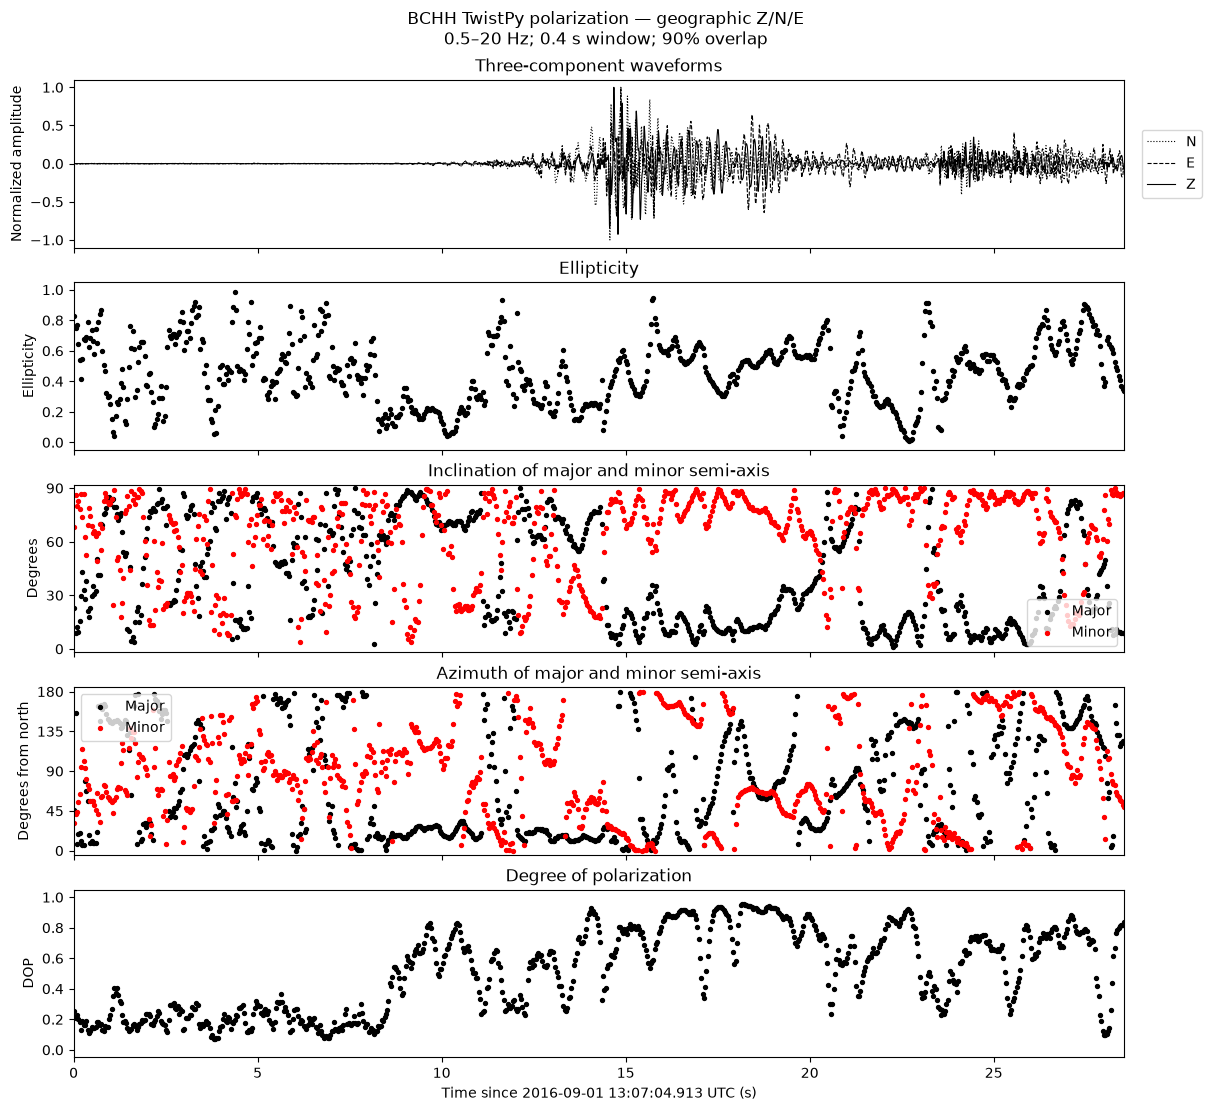

Saved: /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/130_analyze_seismic_polarization/twistpy_style_zne.pdf
BCHH TwistPy polarization — source-relative Z/R/T: plotting 793 polarization windows from 2016-09-01T13:07:04.913000Z to 2016-09-01T13:07:33.458000Z


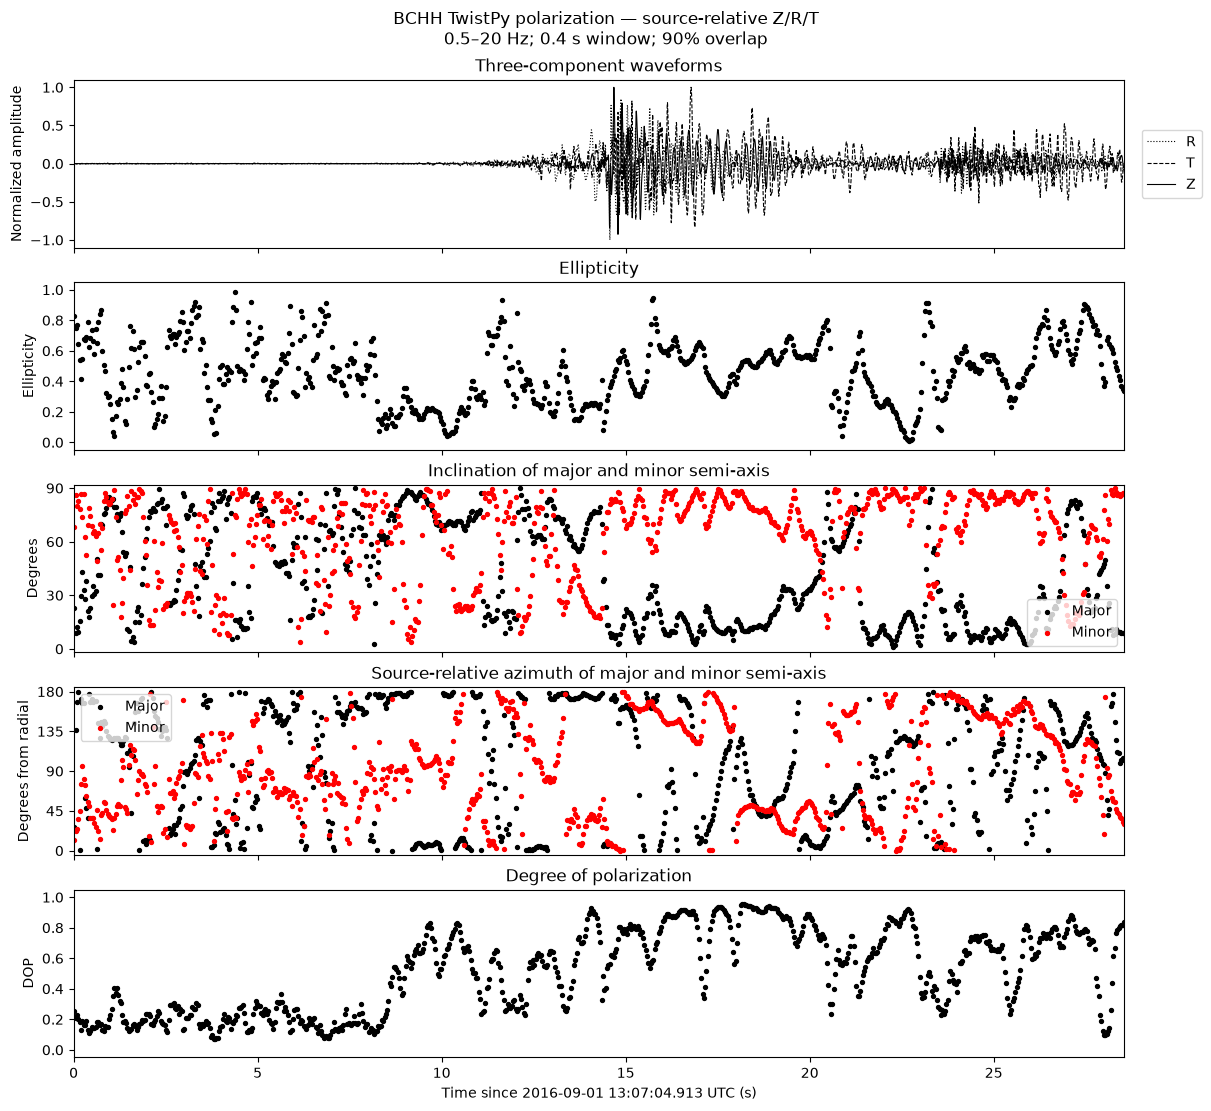

Saved: /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/130_analyze_seismic_polarization/twistpy_style_zrt.pdf


In [9]:
# Broad-context TwistPy-style figures.
plot_twistpy_style(
    st_analysis_zne,
    components=("N", "E", "Z"),
    labels=("N", "E", "Z"),
    starttime=PLOT_START,
    endtime=PLOT_END,
    azimuth_mode="geographic",
    output_path=TWISTPY_ZNE_FIGURE,
    title="BCHH TwistPy polarization — geographic Z/N/E",
)

plot_twistpy_style(
    st_analysis_zrt,
    components=("R", "T", "Z"),
    labels=("R", "T", "Z"),
    starttime=PLOT_START,
    endtime=PLOT_END,
    azimuth_mode="source_relative",
    output_path=TWISTPY_ZRT_FIGURE,
    title="BCHH TwistPy polarization — source-relative Z/R/T",
)


In [10]:
def robust_symmetric_ylim(
    values: np.ndarray,
    percentile: float = 99.5,
    padding: float = 1.08,
) -> tuple[float, float]:
    """Return robust symmetric limits from the samples currently displayed."""
    values = np.asarray(values, dtype=float)
    finite = values[np.isfinite(values)]
    if finite.size == 0:
        return -1.0, 1.0

    amplitude = np.nanpercentile(np.abs(finite), percentile)
    if not np.isfinite(amplitude) or amplitude <= 0.0:
        amplitude = np.nanmax(np.abs(finite))
    if not np.isfinite(amplitude) or amplitude <= 0.0:
        amplitude = 1.0
    amplitude *= padding
    return -amplitude, amplitude


def make_zrt_polarization_zoom(
    *,
    reference_time: UTCDateTime,
    event_label: str,
    zoom_start_s: float,
    zoom_end_s: float,
    output_path: Path,
    common_waveform_scale: bool,
    predicted_airwave_delay_s: float | None = ACOUSTIC_TRAVEL_TIME_S,
) -> None:
    """Plot event-relative Z/R/T waveforms and polarization attributes."""
    reference_time = UTCDateTime(reference_time)
    plot_start = reference_time + float(zoom_start_s)
    plot_end = reference_time + float(zoom_end_s)
    if plot_end <= plot_start:
        raise ValueError(f"Invalid plot interval: {plot_start} to {plot_end}")

    plot_stream = st_analysis_zrt.copy().trim(plot_start, plot_end, pad=False)
    plot_pol = subset_polarization(plot_start, plot_end)
    plot_pol["event_relative_time_s"] = (
        plot_pol["time_epoch_s"] - utc_epoch_seconds(reference_time)
    )

    waveform_data = {}
    for component in ("Z", "R", "T"):
        trace = unique_component(plot_stream, component)
        waveform_data[component] = {
            "time_s": trace.times(reftime=reference_time),
            "data": np.asarray(trace.data, dtype=float),
        }

    common_ylim = None
    if common_waveform_scale:
        common_ylim = robust_symmetric_ylim(
            np.concatenate([
                waveform_data[component]["data"]
                for component in ("Z", "R", "T")
            ])
        )

    fig, axes = plt.subplots(
        5, 1, figsize=(12, 11), sharex=True, constrained_layout=True,
        gridspec_kw={"height_ratios": [1.0, 1.0, 1.0, 0.95, 0.95]},
    )

    for ax, component in zip(axes[:3], ("Z", "R", "T")):
        time_s = waveform_data[component]["time_s"]
        data = waveform_data[component]["data"]
        ax.plot(time_s, data, color="black", lw=0.8)
        ax.set_ylabel(f"{component}\n(m s$^{{-1}}$)")
        ax.set_ylim(*(common_ylim or robust_symmetric_ylim(data)))
        ax.grid(True, axis="x", alpha=0.20)

    relative_time_s = plot_pol["event_relative_time_s"]
    axes[3].plot(relative_time_s, plot_pol["linearity"], label="Linearity", lw=1.0)
    axes[3].plot(relative_time_s, plot_pol["rectilinearity"], label="Rectilinearity", lw=1.0)
    axes[3].plot(relative_time_s, plot_pol["planarity"], label="Planarity", lw=1.0)
    axes[3].set_ylim(-0.05, 1.05)
    axes[3].set_ylabel("Covariance\nattributes")
    axes[3].legend(loc="upper right", ncol=3)
    axes[3].grid(True, alpha=0.20)

    axes[4].plot(relative_time_s, plot_pol["ellipticity"], label="Ellipticity", lw=1.0)
    axes[4].plot(
        relative_time_s,
        plot_pol["degree_of_polarization"],
        label="TwistPy DOP",
        lw=1.0,
    )
    axes[4].set_ylim(-0.05, 1.05)
    axes[4].set_ylabel("TwistPy\nattributes")
    axes[4].set_xlabel(f"Time relative to adopted {event_label} time (s)")
    axes[4].legend(loc="upper right", ncol=2)
    axes[4].grid(True, alpha=0.20)

    for panel_index, ax in enumerate(axes):
        # Show every named source and its predicted BCHH-reference airwave.
        # Closely spaced sources and arrivals can overlap in the same panel.
        for neighboring_label, neighboring_source_time in SOURCE_EVENTS.items():
            source_offset_s = float(neighboring_source_time - reference_time)
            is_focal = abs(source_offset_s) < 5e-4
            if zoom_start_s <= source_offset_s <= zoom_end_s:
                ax.axvline(
                    source_offset_s,
                    color="0.05" if is_focal else "0.48",
                    lw=1.05 if is_focal else 0.65,
                    ls="-" if is_focal else ":",
                    label=(
                        f"{event_label} source time"
                        if panel_index == 0 and is_focal else None
                    ),
                )
            if predicted_airwave_delay_s is not None:
                acoustic_offset_s = source_offset_s + predicted_airwave_delay_s
                if zoom_start_s <= acoustic_offset_s <= zoom_end_s:
                    ax.axvline(
                        acoustic_offset_s,
                        color="0.18" if is_focal else "0.68",
                        lw=1.0 if is_focal else 0.65,
                        ls="--",
                        label=(
                            "Focal-event predicted acoustic arrival"
                            if panel_index == 0 and is_focal else None
                        ),
                    )


    axes[0].legend(loc="upper left")
    axes[-1].set_xlim(float(zoom_start_s), float(zoom_end_s))

    scale_description = (
        "common Z/R/T scale" if common_waveform_scale
        else "independent component scales"
    )
    fig.suptitle(
        f"BCHH Z/R/T polarization overview — {event_label}\n"
        f"{FILTER_FREQMIN_HZ:g}–{FILTER_FREQMAX_HZ:g} Hz; "
        f"{WINDOW_LENGTH_S:g} s window; "
        f"zoom={zoom_start_s:g} to {zoom_end_s:g} s; "
        f"{scale_description}"
    )
    fig.savefig(output_path, dpi=220, bbox_inches="tight")
    plt.show()
    print("Saved:", output_path)


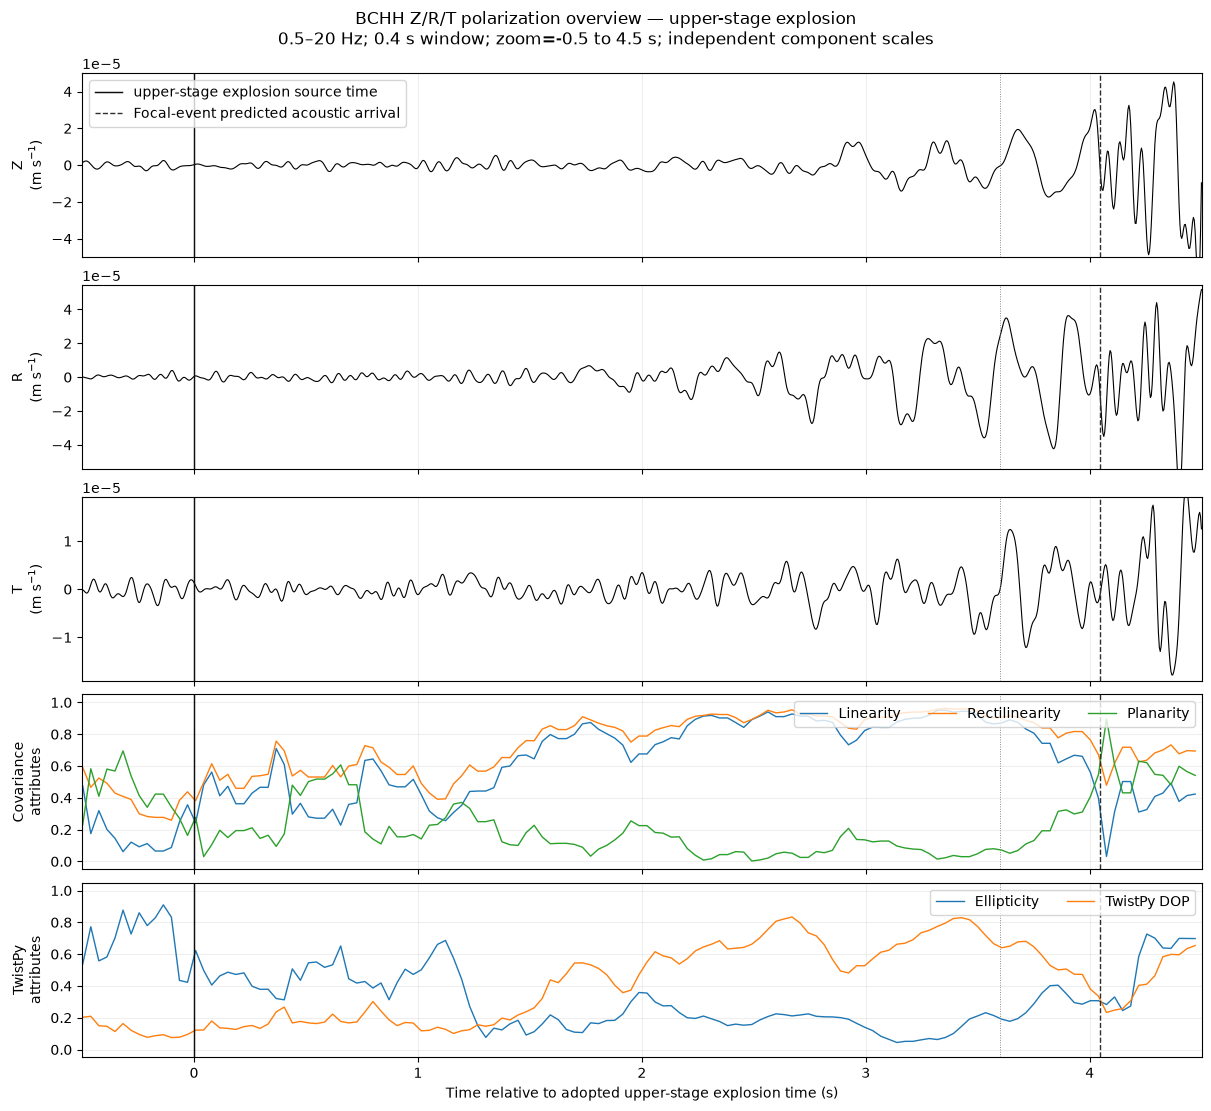

Saved: /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/130_analyze_seismic_polarization/zrt_upper_stage_zoom_independent_scale.pdf


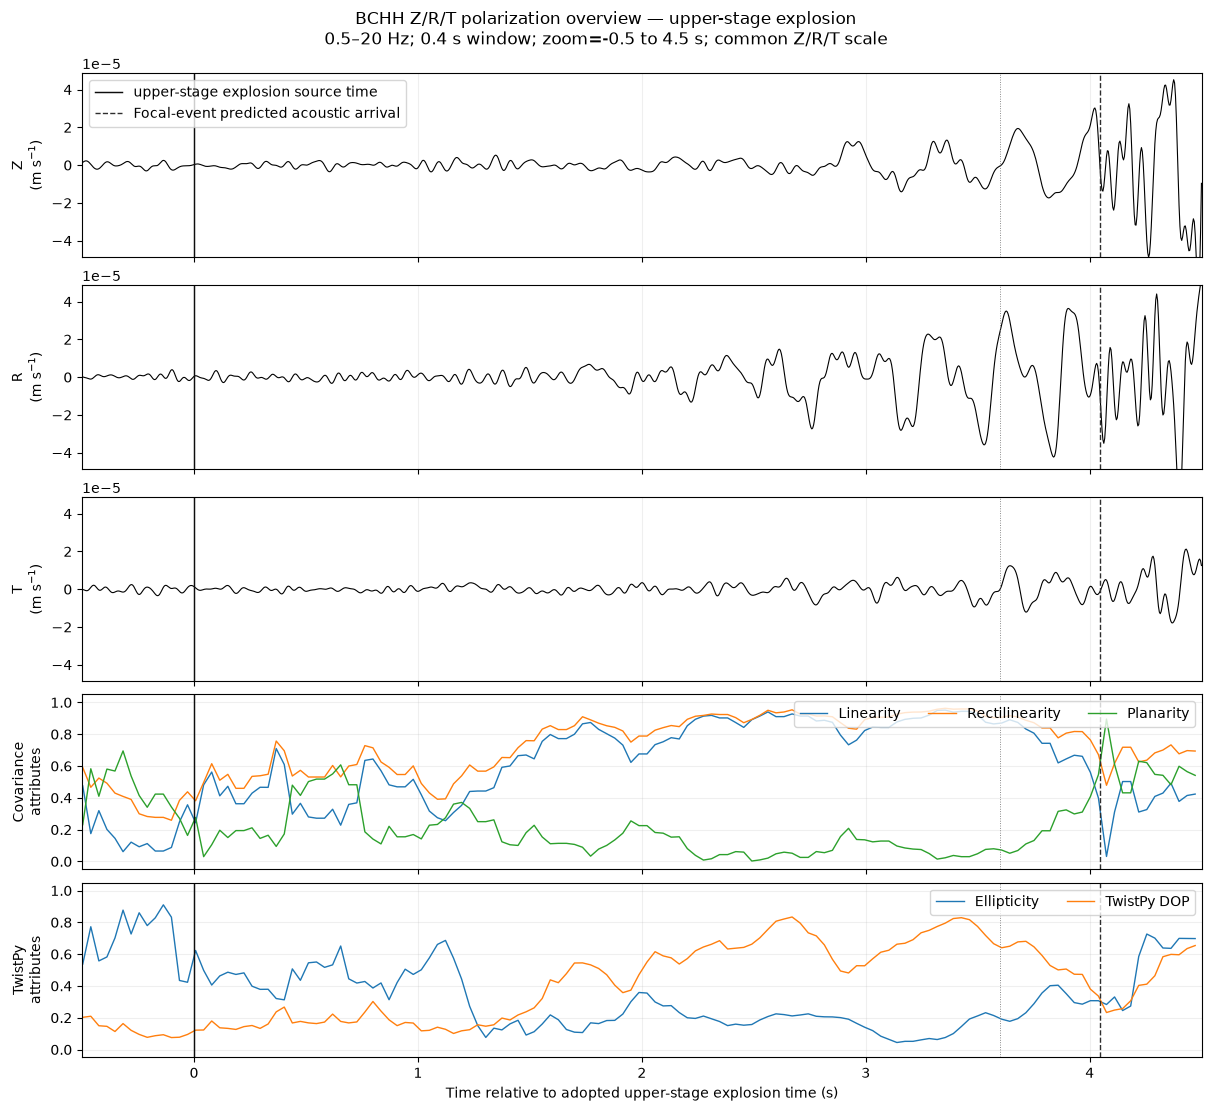

Saved: /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/130_analyze_seismic_polarization/zrt_upper_stage_zoom_common_scale.pdf


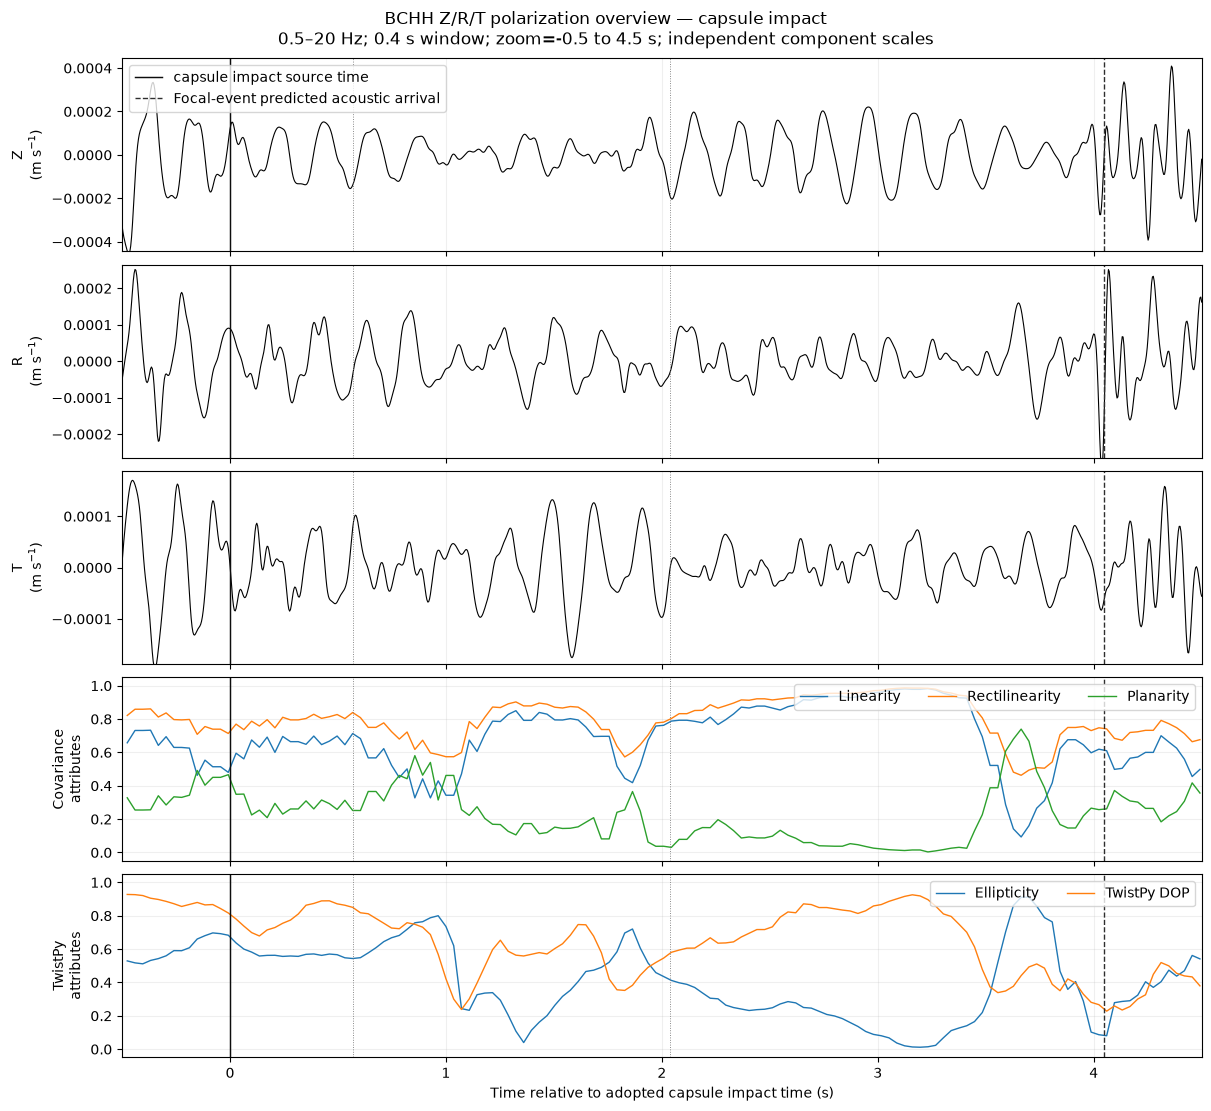

Saved: /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/130_analyze_seismic_polarization/zrt_capsule_impact_zoom_independent_scale.pdf


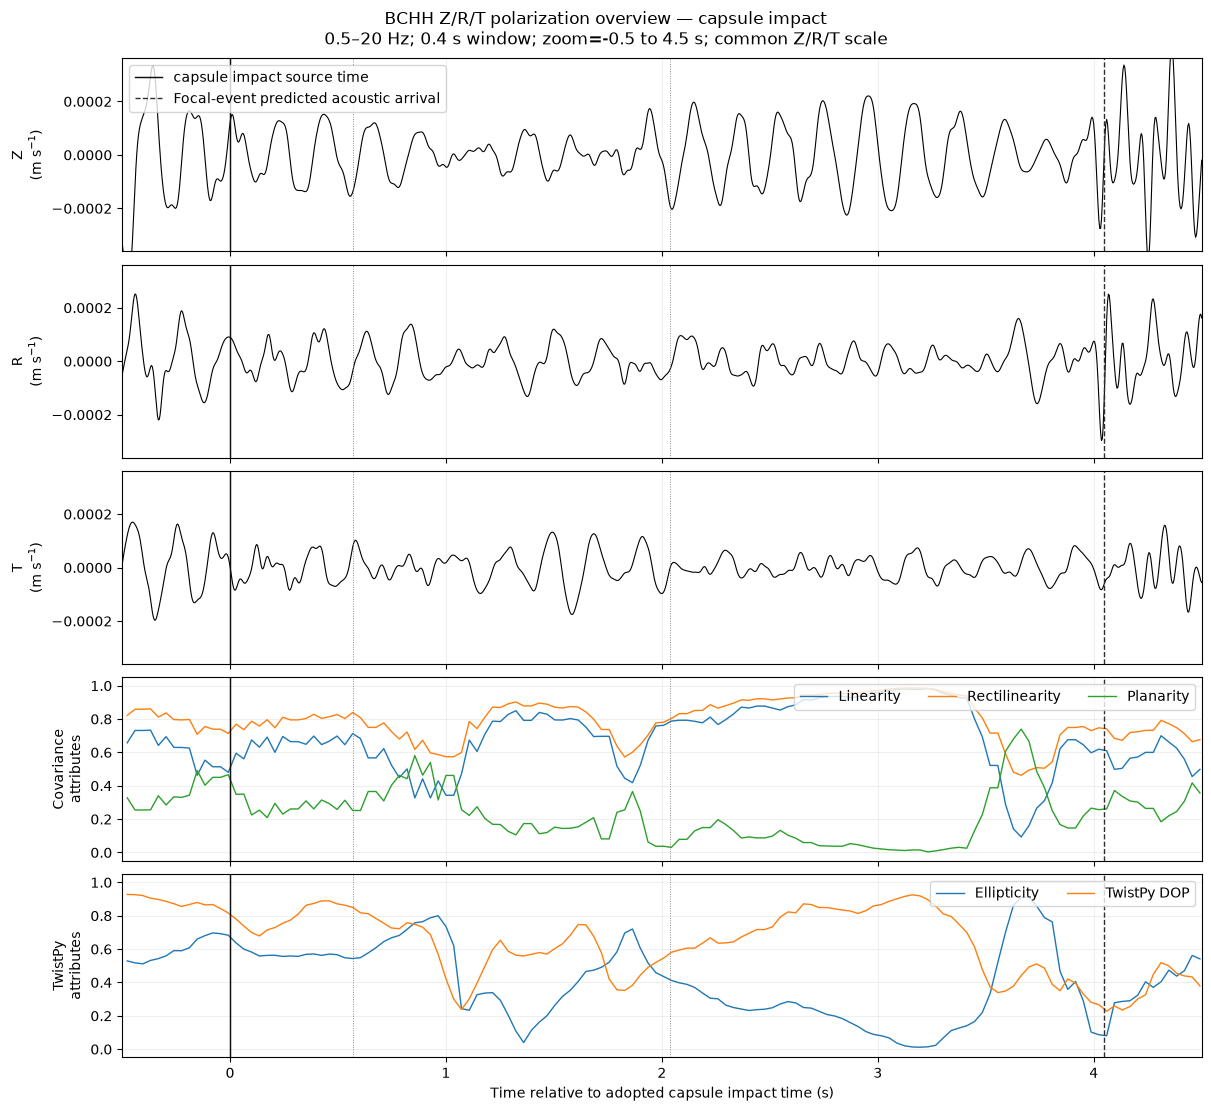

Saved: /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/130_analyze_seismic_polarization/zrt_capsule_impact_zoom_common_scale.pdf


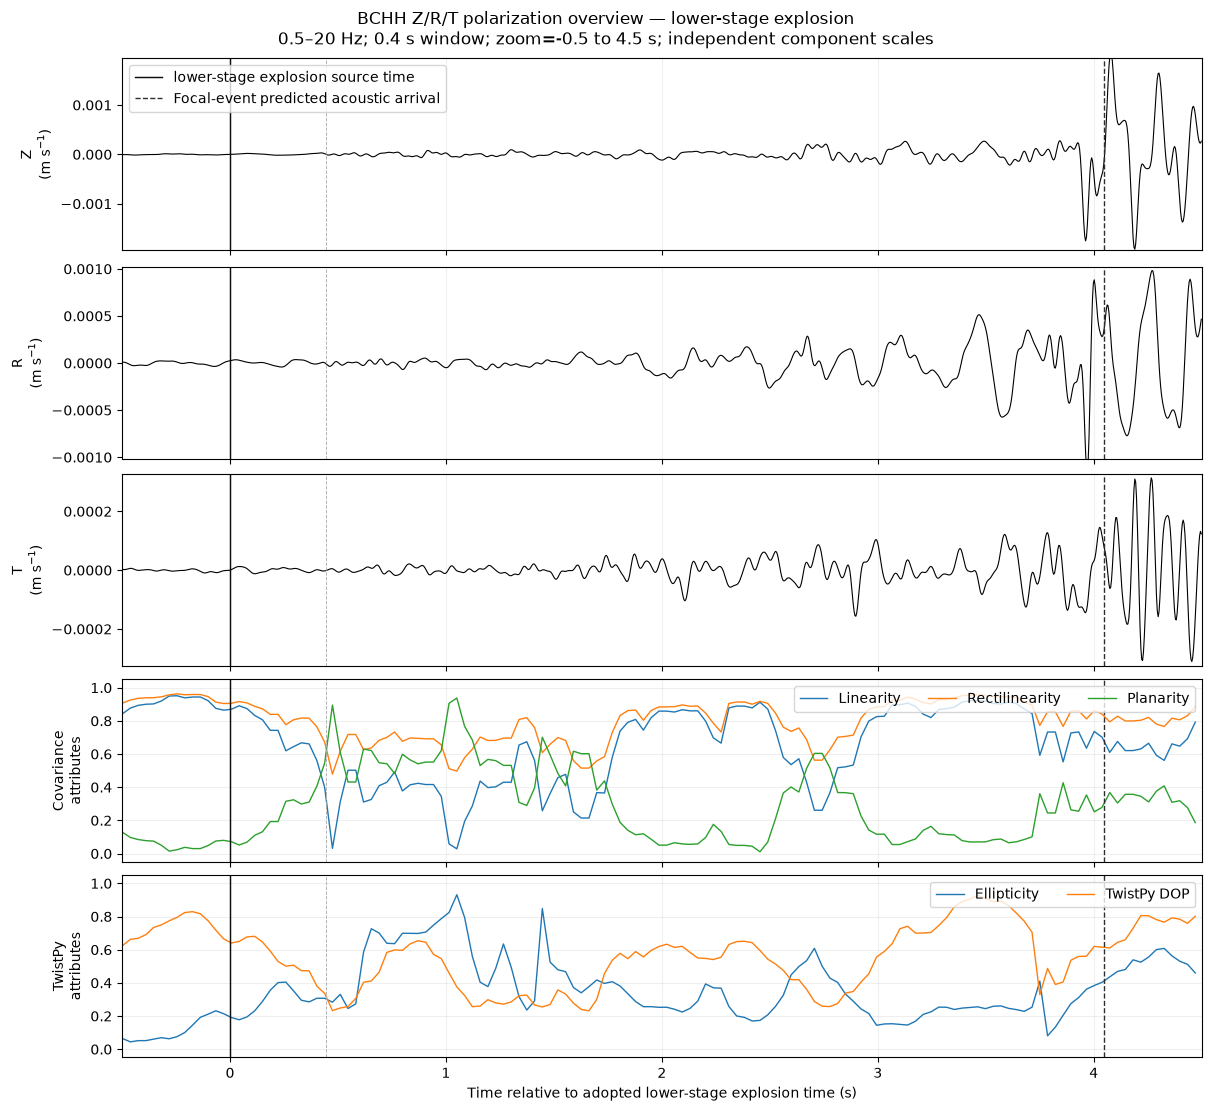

Saved: /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/130_analyze_seismic_polarization/zrt_lower_stage_zoom_independent_scale.pdf


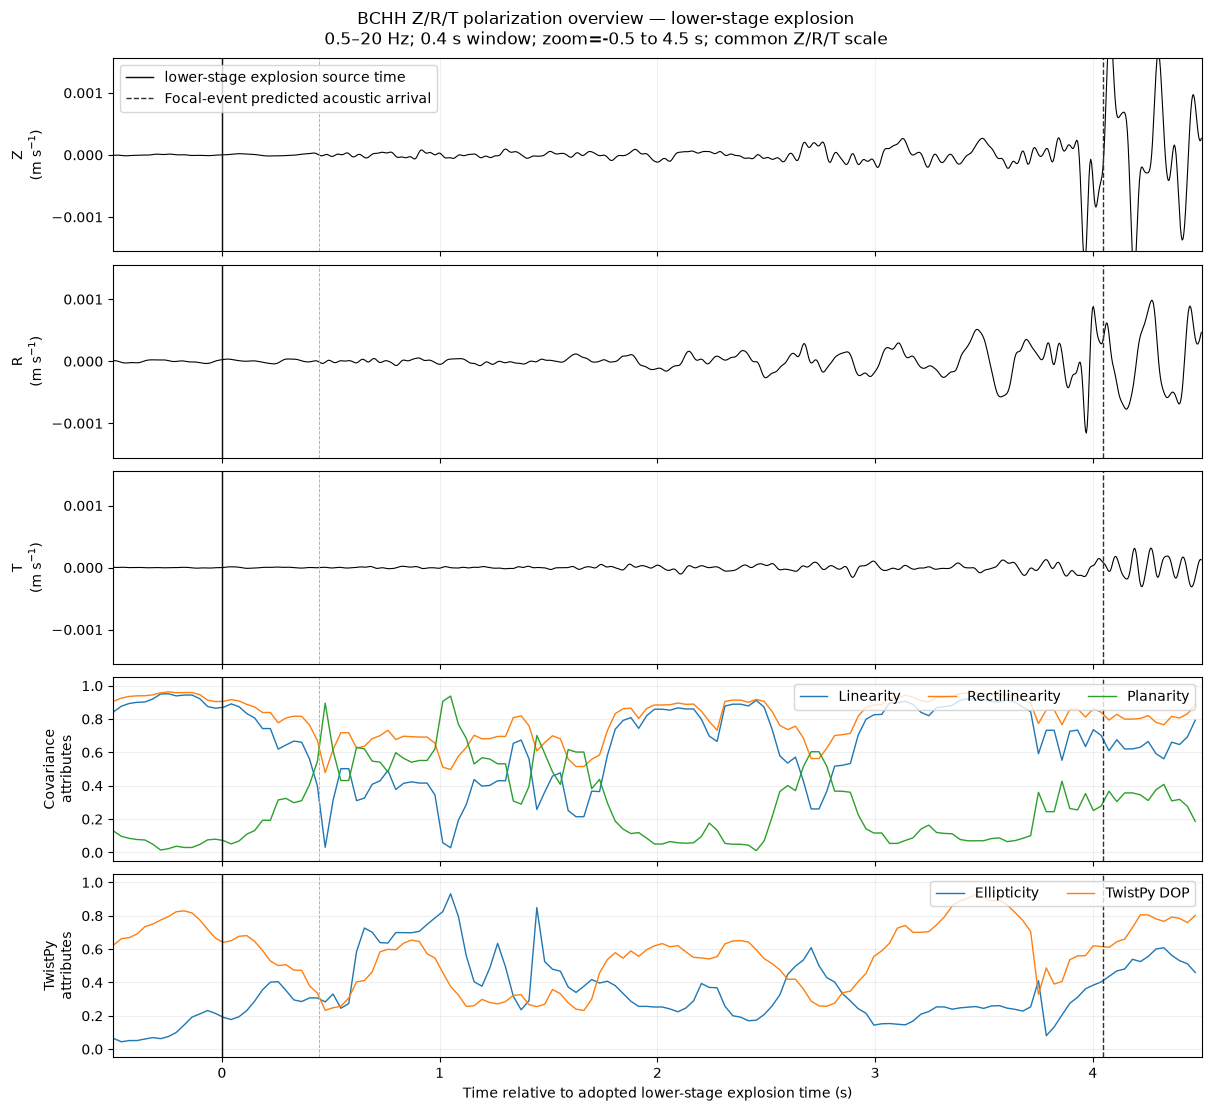

Saved: /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/130_analyze_seismic_polarization/zrt_lower_stage_zoom_common_scale.pdf


In [11]:
EVENT_FIGURES = {}

for event_key, event_cfg in EVENT_ZOOMS.items():
    independent_path = (
        config.NB130_DIR / f"zrt_{event_key}_zoom_independent_scale.pdf"
    )
    common_path = (
        config.NB130_DIR / f"zrt_{event_key}_zoom_common_scale.pdf"
    )

    common_kwargs = {
        "reference_time": event_cfg["time"],
        "event_label": event_cfg["label"],
        "zoom_start_s": event_cfg["zoom"][0],
        "zoom_end_s": event_cfg["zoom"][1],
    }

    make_zrt_polarization_zoom(
        **common_kwargs,
        output_path=independent_path,
        common_waveform_scale=False,
    )
    make_zrt_polarization_zoom(
        **common_kwargs,
        output_path=common_path,
        common_waveform_scale=True,
    )

    EVENT_FIGURES[f"{event_key}_independent"] = independent_path
    EVENT_FIGURES[f"{event_key}_common"] = common_path


## 9. Multiband polarization overview

The following analysis repeats the TwistPy calculation independently in several frequency bands over one common interval spanning pre-event noise and the five named sources. It characterizes how ellipticity, inclination, source-relative azimuth, and degree of polarization vary through the sequence.

Source markers use the configured infrasound-derived origin times. Dashed markers show predicted ground-coupled-airwave arrivals using the Notebook 03 meteorological effective speed. No P, S, or surface-wave picks are made here.


Computing covariance matrices...
Covariance matrices computed!
Computing polarization attributes...
Polarization attributes have been computed!
Computing polarization attributes...
Polarization attributes have been computed!


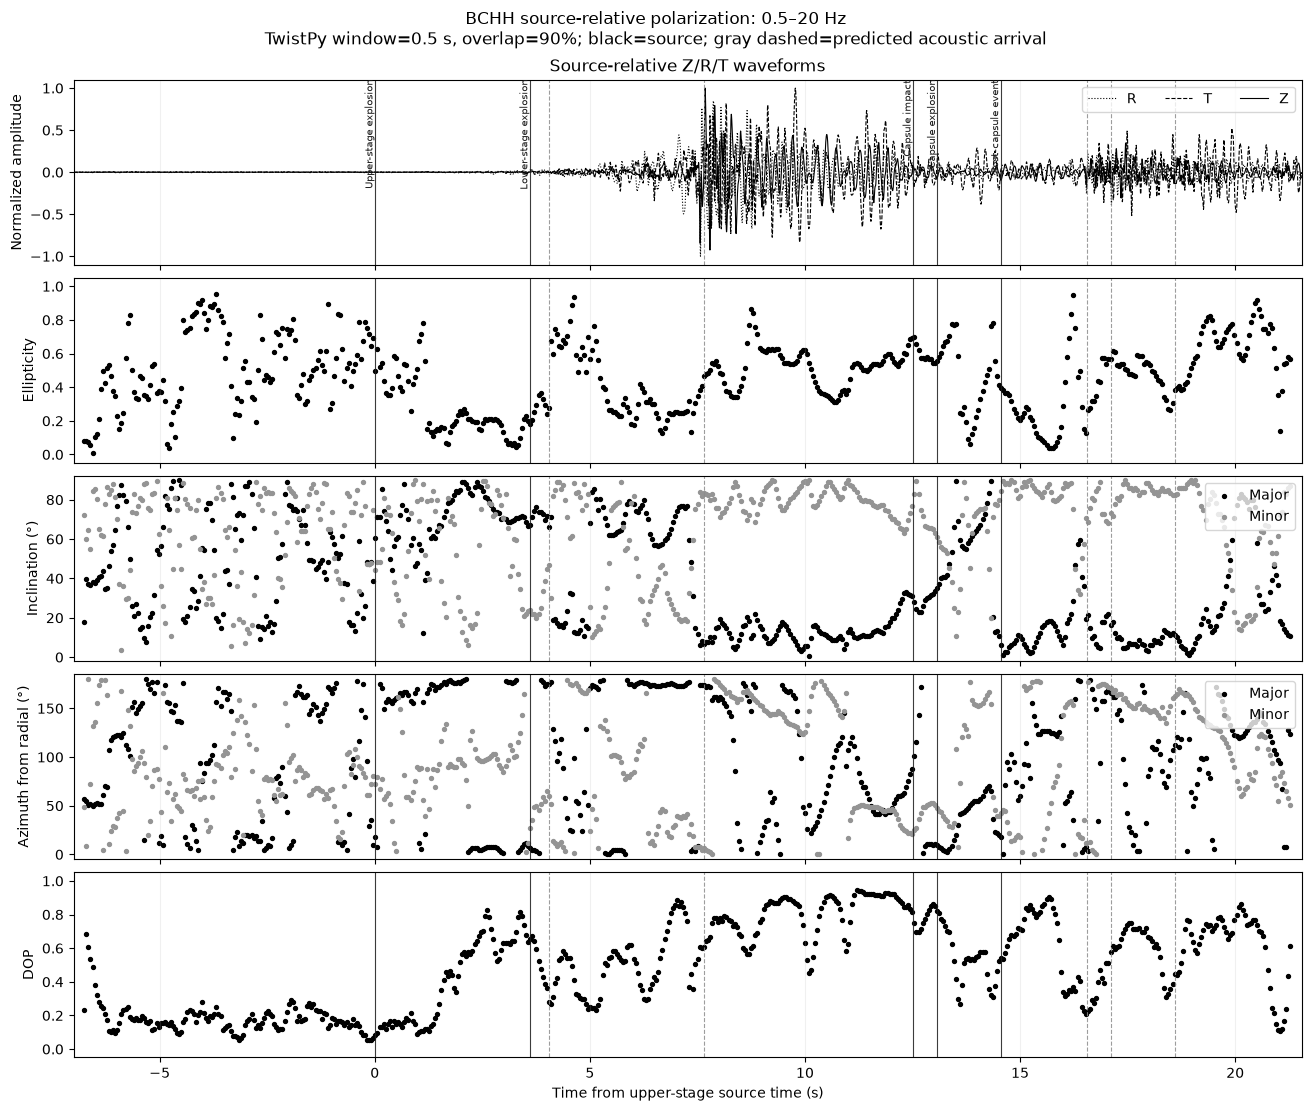

Saved: /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/130_analyze_seismic_polarization/twistpy_source_relative_broad_0p5_20.pdf
Computing covariance matrices...
Covariance matrices computed!
Computing polarization attributes...
Polarization attributes have been computed!
Computing polarization attributes...
Polarization attributes have been computed!


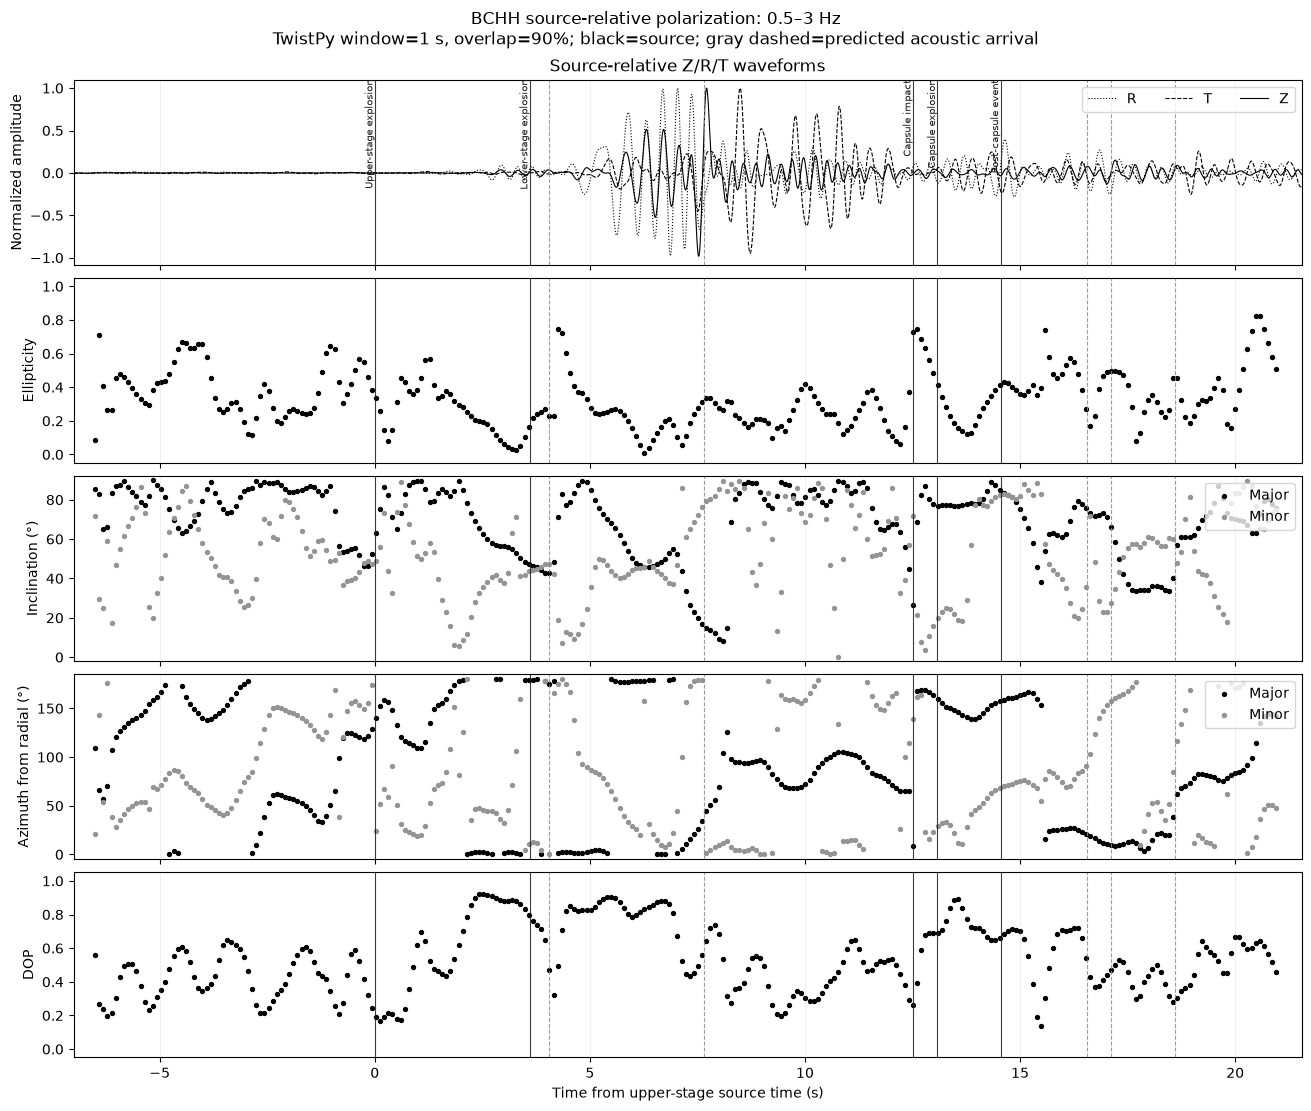

Saved: /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/130_analyze_seismic_polarization/twistpy_source_relative_low_0p5_3.pdf
Computing covariance matrices...
Covariance matrices computed!
Computing polarization attributes...
Polarization attributes have been computed!
Computing polarization attributes...
Polarization attributes have been computed!


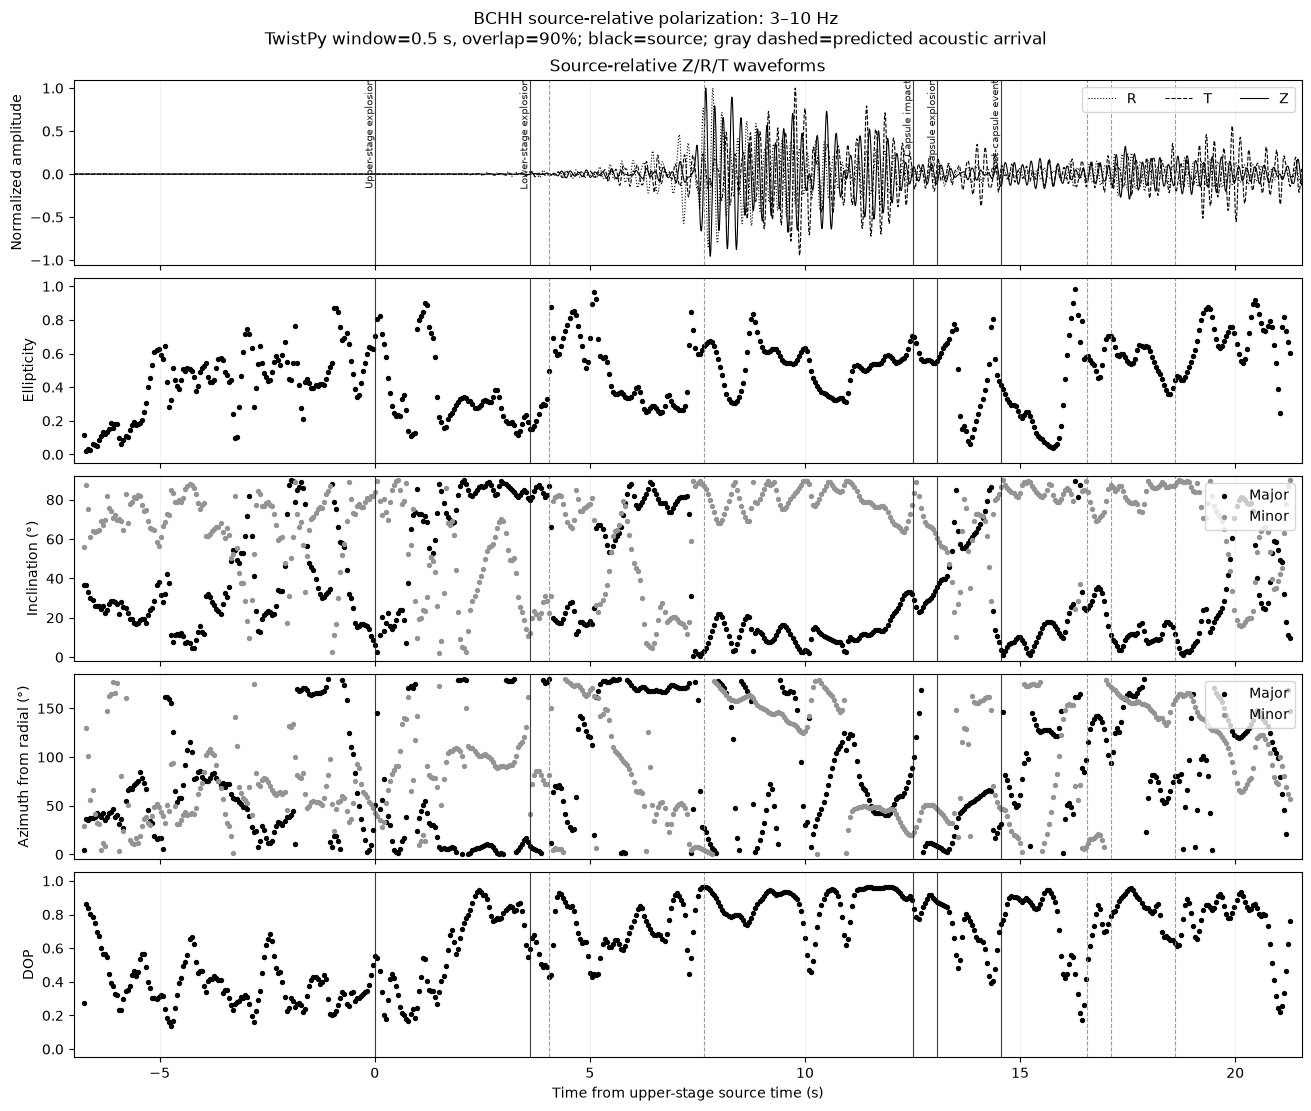

Saved: /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/130_analyze_seismic_polarization/twistpy_source_relative_airwave_3_10.pdf
Computing covariance matrices...
Covariance matrices computed!
Computing polarization attributes...
Polarization attributes have been computed!
Computing polarization attributes...
Polarization attributes have been computed!


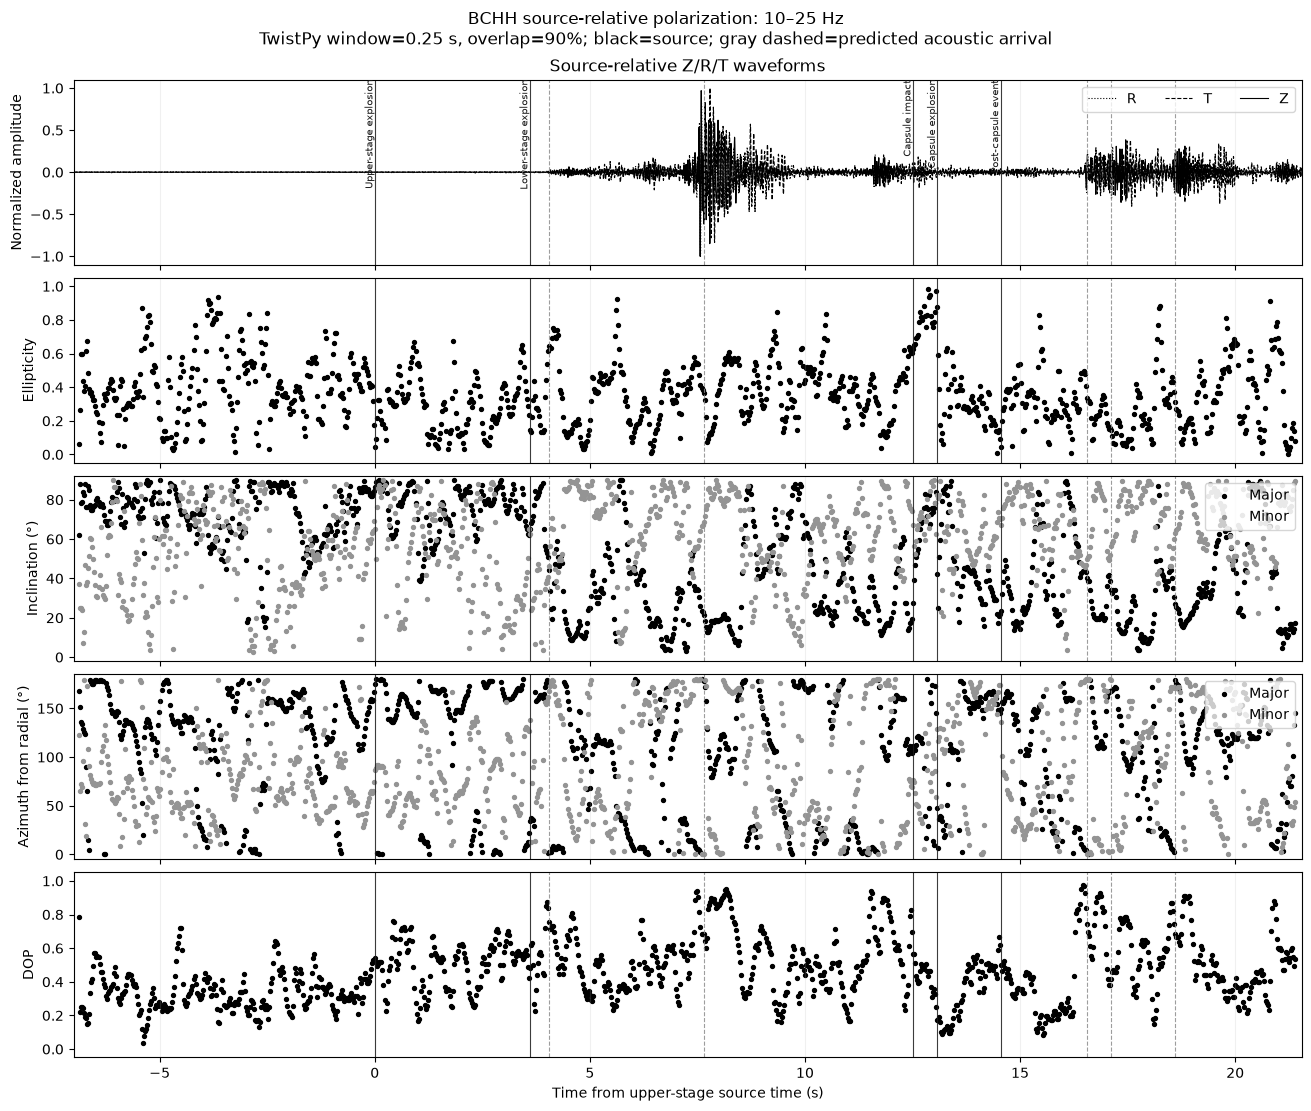

Saved: /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/130_analyze_seismic_polarization/twistpy_source_relative_high_10_25.pdf
Computing covariance matrices...
Covariance matrices computed!
Computing polarization attributes...
Polarization attributes have been computed!
Computing polarization attributes...
Polarization attributes have been computed!


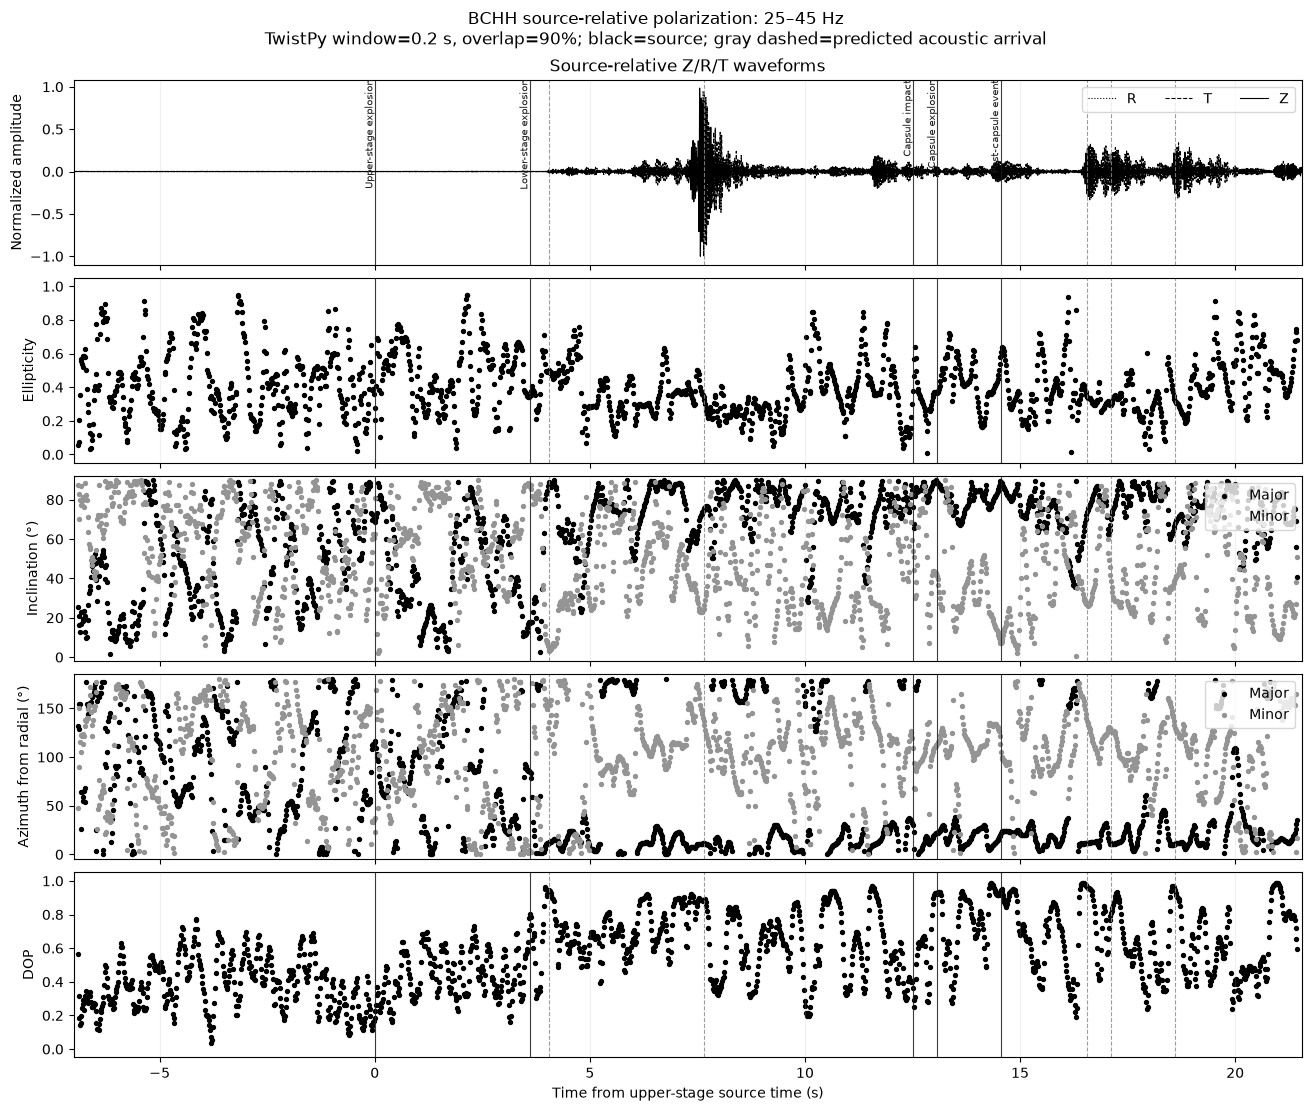

Saved: /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/130_analyze_seismic_polarization/twistpy_source_relative_very_high_25_45.pdf
Saved: /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/130_analyze_seismic_polarization/multiband/multiband_polarization_timeseries.csv


,windows,median_dop,median_ellipticity
band,,,
airwave_3_10,585,0.698002,0.496659
broad_0p5_20,585,0.532796,0.468442
high_10_25,1179,0.442108,0.343696
low_0p5_3,287,0.522045,0.307327
very_high_25_45,1772,0.557238,0.375601


In [12]:
def valid_band_for_stream(
    stream: Stream,
    freqmin_hz: float,
    freqmax_hz: float,
) -> tuple[float, float]:
    """Clip an exploratory band to a safe fraction of the stream Nyquist."""
    sampling_rate = min(float(tr.stats.sampling_rate) for tr in stream)
    nyquist = 0.5 * sampling_rate
    safe_max = 0.95 * nyquist
    fmin = float(freqmin_hz)
    fmax = min(float(freqmax_hz), safe_max)
    if fmin >= fmax:
        raise ValueError(
            f"Band {freqmin_hz}-{freqmax_hz} Hz is invalid for "
            f"sampling rate {sampling_rate:g} Hz (Nyquist={nyquist:g} Hz)."
        )
    return fmin, fmax


def prepare_band_stream(
    stream: Stream,
    freqmin_hz: float,
    freqmax_hz: float,
) -> Stream:
    """Trim with padding, preprocess, bandpass, then trim to the focus window."""
    fmin, fmax = valid_band_for_stream(stream, freqmin_hz, freqmax_hz)
    padding_s = max(5.0, 3.0 / fmin)
    out = stream.copy().trim(PLOT_START - padding_s, PLOT_END + padding_s, pad=False)
    out.detrend("linear")
    out.detrend("demean")
    out.taper(max_percentage=0.05, type="cosine")
    out.filter(
        "bandpass",
        freqmin=fmin,
        freqmax=fmax,
        corners=FILTER_CORNERS,
        zerophase=FILTER_ZEROPHASE,
    )
    out.trim(PLOT_START, PLOT_END, pad=False)
    return out


def twistpy_dataframe_for_band(
    st_zne_band: Stream,
    *,
    band_name: str,
    freqmin_hz: float,
    freqmax_hz: float,
    window_length_s: float,
) -> pd.DataFrame:
    """Run TwistPy on one Z/N/E band and return an absolute-time table."""
    z_band = unique_component(st_zne_band, "Z")
    n_band = unique_component(st_zne_band, "N")
    e_band = unique_component(st_zne_band, "E")
    assert_sample_aligned((z_band, n_band, e_band))

    analysis_band = TimeDomainAnalysis3C(
        N=n_band,
        E=e_band,
        Z=z_band,
        window={
            "window_length_seconds": float(window_length_s),
            "overlap": float(WINDOW_OVERLAP),
        },
        timeaxis="rel",
    )
    analysis_band.polarization_analysis()

    relative_s = np.asarray(analysis_band.t_windows, dtype=float)
    start_epoch = utc_epoch_seconds(z_band.stats.starttime)
    time_epoch_s = start_epoch + relative_s

    result = pd.DataFrame({
        "band": band_name,
        "freqmin_hz": freqmin_hz,
        "freqmax_hz": freqmax_hz,
        "window_length_s": window_length_s,
        "time_epoch_s": time_epoch_s,
        "time_from_upper_stage_s": time_epoch_s - utc_epoch_seconds(UPPER_STAGE_SOURCE_TIME),
        "ellipticity": np.asarray(analysis_band.elli, dtype=float),
        "degree_of_polarization": np.asarray(analysis_band.dop, dtype=float),
        "major_azimuth_deg": np.asarray(analysis_band.azi1, dtype=float) % 180.0,
        "minor_azimuth_deg": np.asarray(analysis_band.azi2, dtype=float) % 180.0,
        "major_inclination_deg": np.asarray(analysis_band.inc1, dtype=float),
        "minor_inclination_deg": np.asarray(analysis_band.inc2, dtype=float),
    })
    result["major_source_relative_azimuth_deg"] = (
        result["major_azimuth_deg"] - back_azimuth_deg
    ) % 180.0
    result["minor_source_relative_azimuth_deg"] = (
        result["minor_azimuth_deg"] - back_azimuth_deg
    ) % 180.0
    result["time_utc"] = [str(UTCDateTime(v)) for v in result["time_epoch_s"]]
    return result


def add_event_timing_annotations(
    ax,
    *,
    include_labels: bool = False,
) -> None:
    """Add named source times and predicted ground-coupled-airwave arrivals."""
    _, ymax = ax.get_ylim()
    for label, source_time in SOURCE_EVENTS.items():
        source_x = float(source_time - UPPER_STAGE_SOURCE_TIME)
        acoustic_x = source_x + ACOUSTIC_TRAVEL_TIME_S
        ax.axvline(source_x, color="0.10", lw=0.8, alpha=EVENT_MARKER_ALPHA)
        ax.axvline(acoustic_x, color="0.55", lw=0.8, ls="--", alpha=EVENT_MARKER_ALPHA)
        if include_labels:
            ax.text(
                source_x,
                ymax,
                label,
                rotation=90,
                ha="right",
                va="top",
                fontsize=7,
                color="0.10",
            )


multiband_frames = []
multiband_streams_zrt = {}

for band_name, (requested_fmin, requested_fmax) in POLARIZATION_BANDS_HZ.items():
    fmin, fmax = valid_band_for_stream(st_zne, requested_fmin, requested_fmax)
    st_band_zne = prepare_band_stream(st_zne, fmin, fmax)
    st_band_zrt = prepare_band_stream(st_zrt, fmin, fmax)
    multiband_streams_zrt[band_name] = st_band_zrt

    window_length_s = BAND_WINDOW_LENGTH_S[band_name]
    band_df = twistpy_dataframe_for_band(
        st_band_zne,
        band_name=band_name,
        freqmin_hz=fmin,
        freqmax_hz=fmax,
        window_length_s=window_length_s,
    )
    multiband_frames.append(band_df)

    output_path = config.NB130_DIR / f"twistpy_source_relative_{band_name}.pdf"
    fig, axes = plt.subplots(5, 1, figsize=(13, 11), sharex=True, constrained_layout=True)

    for component, linestyle in zip(("R", "T", "Z"), (":", "--", "-")):
        tr = unique_component(st_band_zrt, component)
        axes[0].plot(
            tr.times(reftime=UPPER_STAGE_SOURCE_TIME),
            normalized_data(tr),
            color="black",
            ls=linestyle,
            lw=0.8,
            label=component,
        )
    axes[0].set_ylabel("Normalized amplitude")
    axes[0].set_title("Source-relative Z/R/T waveforms")
    axes[0].legend(loc="upper right", ncol=3)

    x = band_df["time_from_upper_stage_s"]
    axes[1].scatter(x, band_df["ellipticity"], s=8, c="black")
    axes[1].set_ylim(-0.05, 1.05)
    axes[1].set_ylabel("Ellipticity")

    axes[2].scatter(x, band_df["major_inclination_deg"], s=8, c="black", label="Major")
    axes[2].scatter(x, band_df["minor_inclination_deg"], s=8, c="0.58", label="Minor")
    axes[2].set_ylim(-2, 92)
    axes[2].set_ylabel("Inclination (°)")
    axes[2].legend(loc="upper right")

    axes[3].scatter(x, band_df["major_source_relative_azimuth_deg"], s=8, c="black", label="Major")
    axes[3].scatter(x, band_df["minor_source_relative_azimuth_deg"], s=8, c="0.58", label="Minor")
    axes[3].set_ylim(-5, 185)
    axes[3].set_ylabel("Azimuth from radial (°)")
    axes[3].legend(loc="upper right")

    axes[4].scatter(x, band_df["degree_of_polarization"], s=8, c="black")
    axes[4].set_ylim(-0.05, 1.05)
    axes[4].set_ylabel("DOP")
    axes[4].set_xlabel("Time from upper-stage source time (s)")

    for panel_index, ax in enumerate(axes):
        add_event_timing_annotations(ax, include_labels=(panel_index == 0))
        ax.set_xlim(float(PLOT_START - UPPER_STAGE_SOURCE_TIME), float(PLOT_END - UPPER_STAGE_SOURCE_TIME))
        ax.grid(True, axis="x", alpha=0.18)

    fig.suptitle(
        f"BCHH source-relative polarization: {fmin:g}–{fmax:g} Hz\n"
        f"TwistPy window={window_length_s:g} s, overlap={WINDOW_OVERLAP:.0%}; "
        "black=source; gray dashed=predicted acoustic arrival"
    )
    fig.savefig(output_path, dpi=220, bbox_inches="tight")
    plt.show()
    print("Saved:", output_path)

multiband_polarization = pd.concat(multiband_frames, ignore_index=True)
multiband_polarization.to_csv(MULTIBAND_TABLE, index=False)
print("Saved:", MULTIBAND_TABLE)
display(multiband_polarization.groupby("band").agg(
    windows=("degree_of_polarization", "size"),
    median_dop=("degree_of_polarization", "median"),
    median_ellipticity=("ellipticity", "median"),
))


## 10. Cross-band comparison figure

This compact figure compares DOP and ellipticity across the full named-event sequence. Every row uses the same time axis, source markers, and predicted ground-coupled-airwave arrivals.


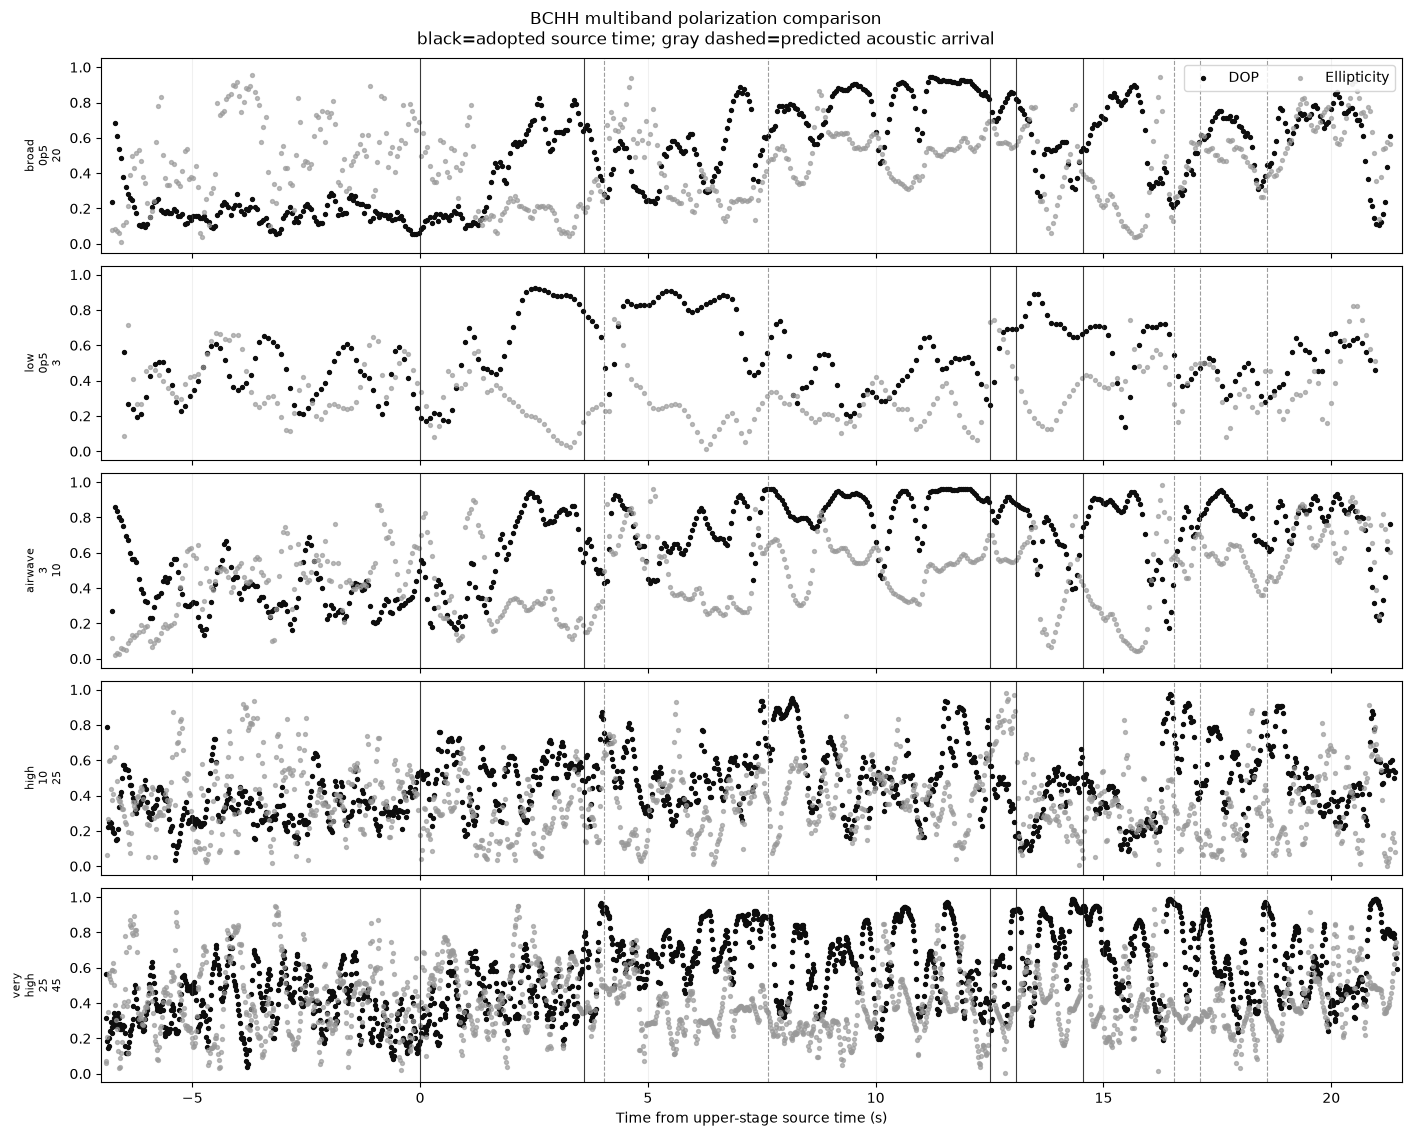

Saved: /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/130_analyze_seismic_polarization/multiband_polarization_comparison.pdf


In [13]:
fig, axes = plt.subplots(
    len(POLARIZATION_BANDS_HZ),
    1,
    figsize=(14, 2.25 * len(POLARIZATION_BANDS_HZ)),
    sharex=True,
    constrained_layout=True,
)

for ax, band_name in zip(np.atleast_1d(axes), POLARIZATION_BANDS_HZ):
    band_df = multiband_polarization.loc[
        multiband_polarization["band"] == band_name
    ]
    ax.scatter(
        band_df["time_from_upper_stage_s"],
        band_df["degree_of_polarization"],
        s=8,
        color="0.05",
        label="DOP",
    )
    ax.scatter(
        band_df["time_from_upper_stage_s"],
        band_df["ellipticity"],
        s=8,
        color="0.60",
        alpha=0.65,
        label="Ellipticity",
    )
    ax.set_ylim(-0.05, 1.05)
    ax.set_ylabel(band_name.replace("_", "\n"), fontsize=8)
    add_event_timing_annotations(ax, include_labels=False)
    ax.grid(True, axis="x", alpha=0.18)

axes[0].legend(loc="upper right", ncol=2)
axes[-1].set_xlabel("Time from upper-stage source time (s)")
axes[-1].set_xlim(
    float(PLOT_START - UPPER_STAGE_SOURCE_TIME),
    float(PLOT_END - UPPER_STAGE_SOURCE_TIME),
)
fig.suptitle(
    "BCHH multiband polarization comparison\n"
    "black=adopted source time; gray dashed=predicted acoustic arrival"
)
fig.savefig(MULTIBAND_COMPARISON_FIGURE, dpi=220, bbox_inches="tight")
plt.show()
print("Saved:", MULTIBAND_COMPARISON_FIGURE)


## 11. High-resolution Z/R/T spectrograms

SciPy computes the time-frequency arrays using Hann-windowed, 90%-overlapping segments. Custom plotting keeps all Z/R/T panels on the same event-relative time axis and annotates configured source times and predicted ground-coupled-airwave arrivals.

Two FFT windows are generated:

- **0.40 s:** better timing of closely spaced pulses;
- **1.00 s:** better frequency resolution, at the cost of greater time smearing.

The inferno color map is perceptually uniform, color-vision robust, and monotonic in luminance. No shaded regions are drawn over the spectrograms. Zero padding smooths the displayed frequency grid but does not improve true spectral resolution.


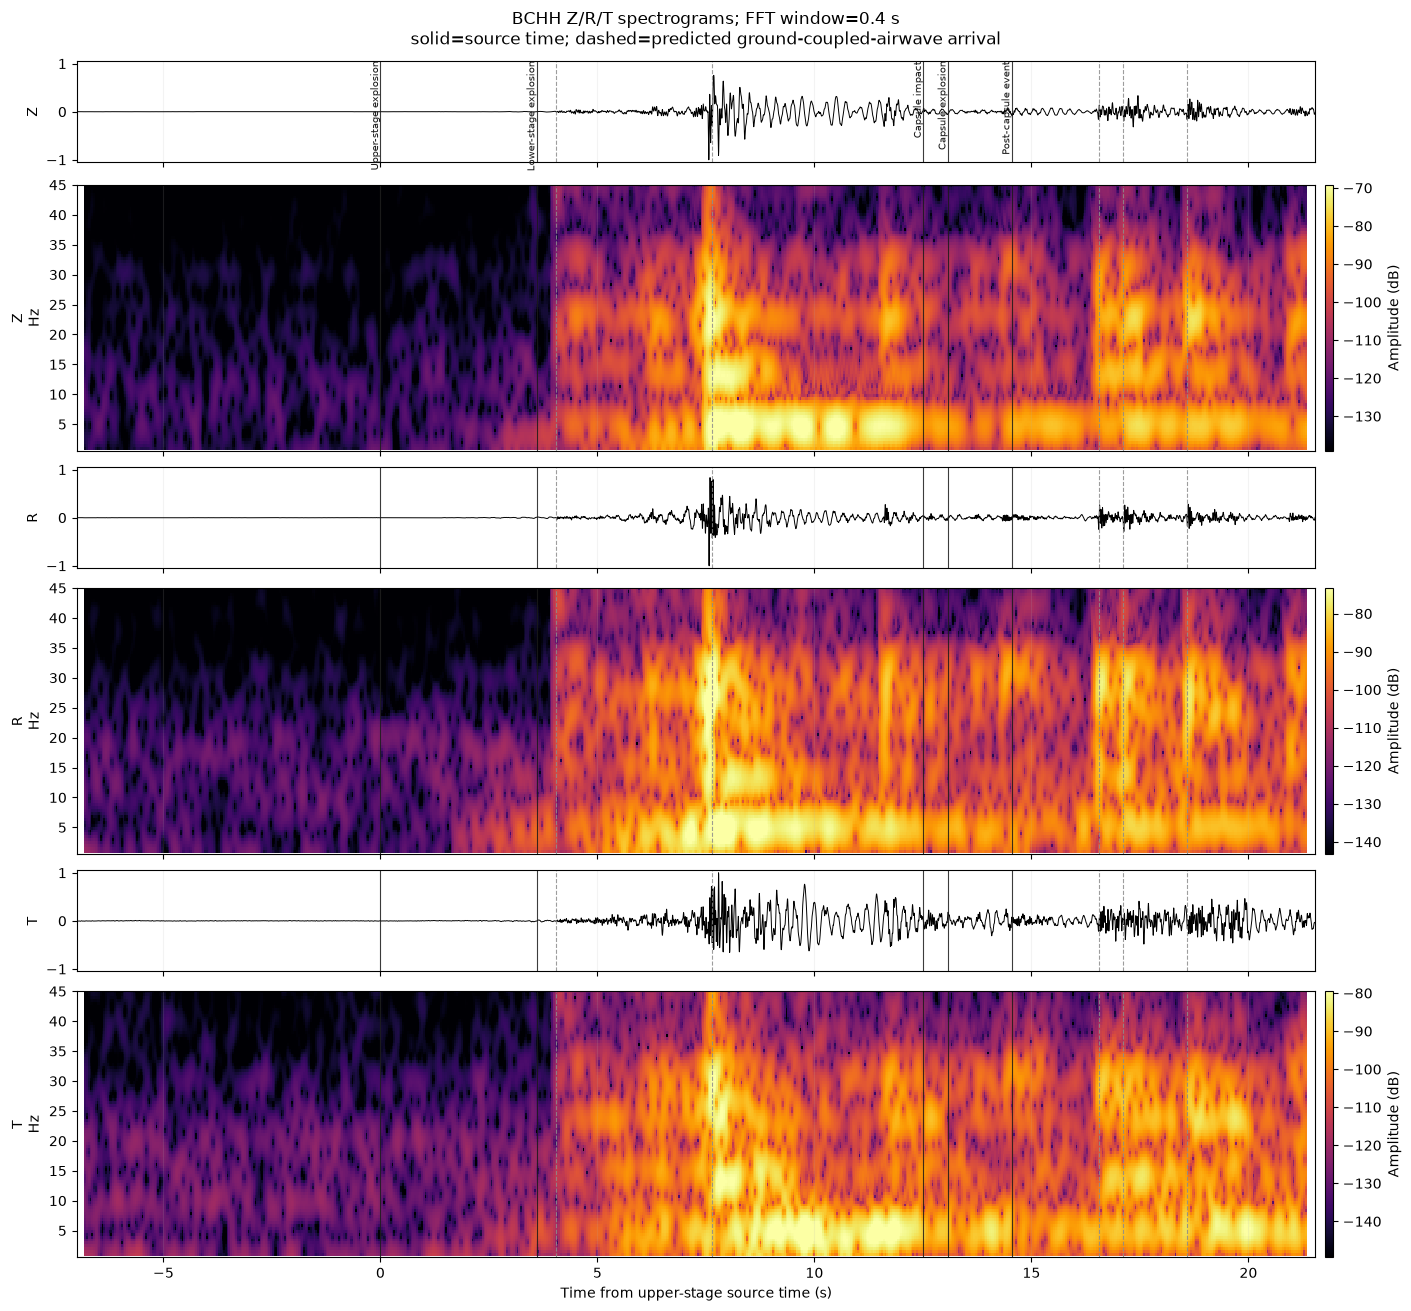

Saved: /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/130_analyze_seismic_polarization/zrt_spectrogram_0p4s.pdf


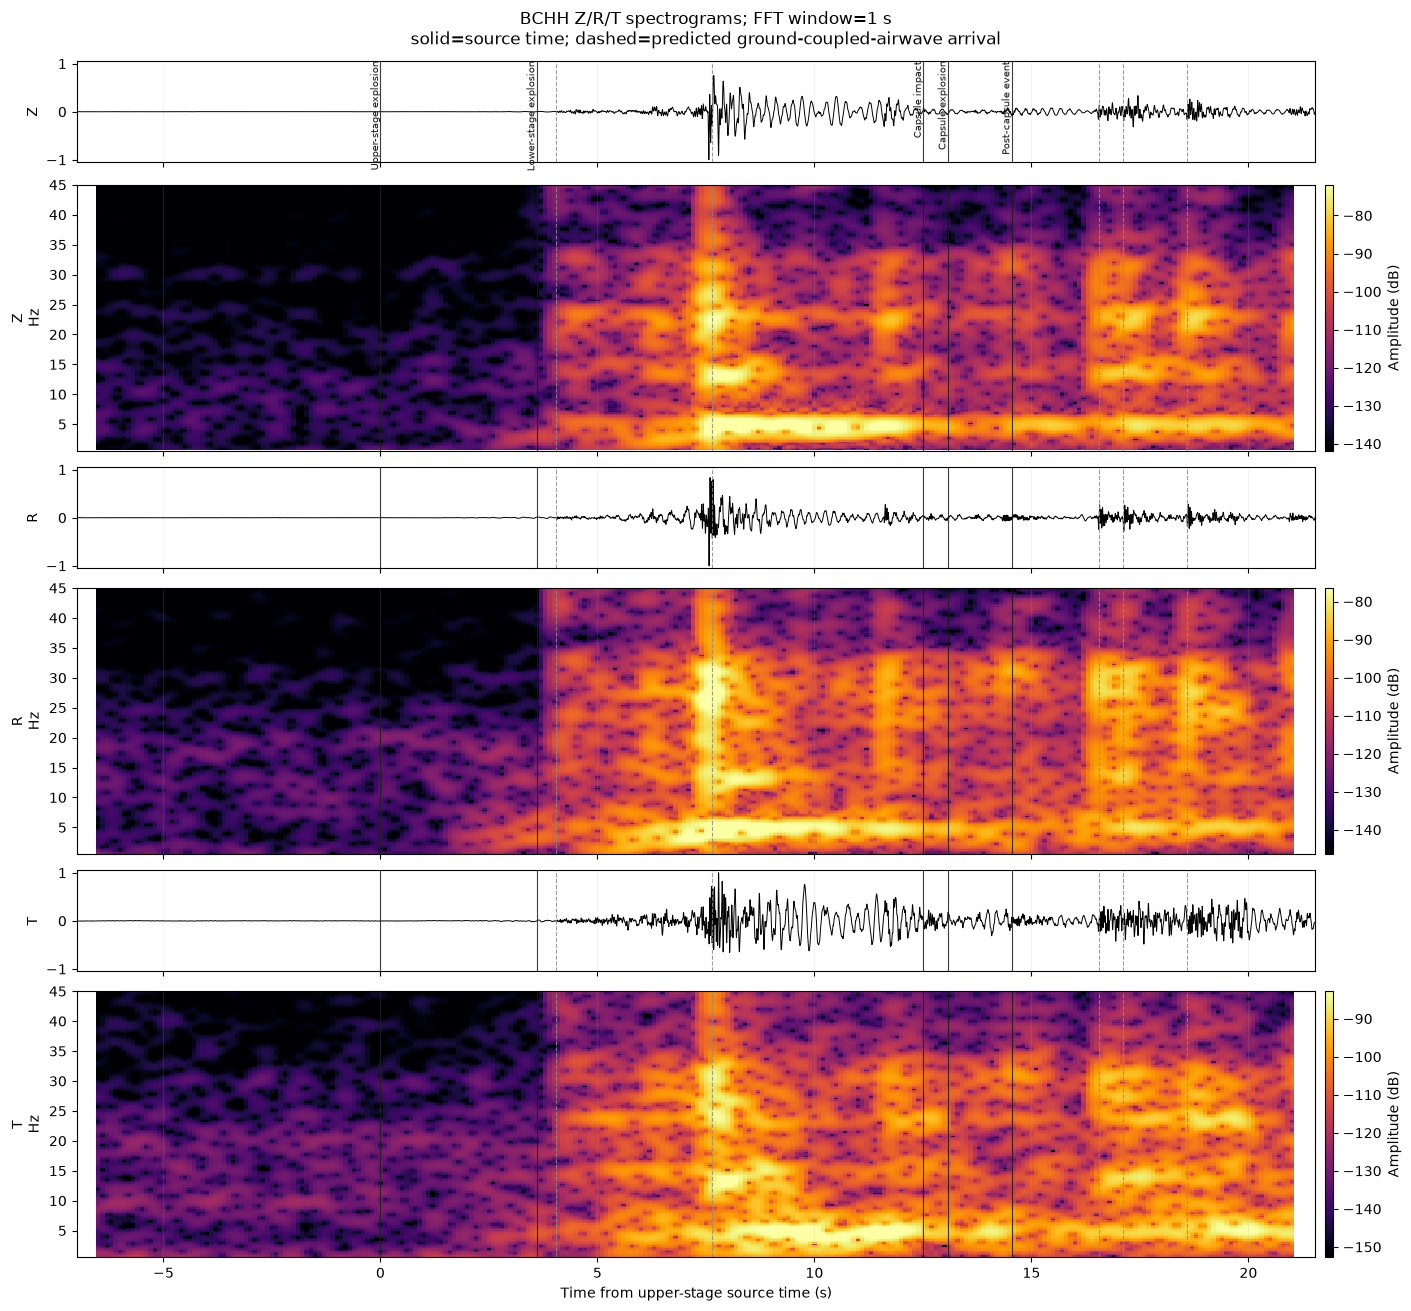

Saved: /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/130_analyze_seismic_polarization/zrt_spectrogram_1p0s.pdf


In [14]:
def compute_zrt_spectrograms(
    stream_zrt: Stream,
    *,
    secs_per_fft: float,
):
    """Compute amplitude spectrogram arrays for a focused Z/R/T stream."""
    st_spec = stream_zrt.copy().trim(PLOT_START, PLOT_END, pad=False)
    st_spec.detrend("linear")
    st_spec.detrend("demean")
    for tr in st_spec:
        sampling_rate_hz = float(tr.stats.sampling_rate)
        nperseg = min(
            len(tr.data),
            max(8, int(round(secs_per_fft * sampling_rate_hz))),
        )
        noverlap = min(nperseg - 1, int(round(0.90 * nperseg)))
        nfft = 4 * 2 ** int(np.ceil(np.log2(nperseg)))
        frequencies_hz, times_s, amplitude = spectrogram(
            np.asarray(tr.data, dtype=float),
            fs=sampling_rate_hz,
            window="hann",
            nperseg=nperseg,
            noverlap=noverlap,
            nfft=nfft,
            detrend=False,
            scaling="spectrum",
            mode="magnitude",
        )
        tr.stats.spectrogramdata = {
            "T": times_s,
            "F": frequencies_hz,
            "S": amplitude,
        }
    return st_spec


def plot_zrt_event_spectrogram(
    stream_spec: Stream,
    *,
    secs_per_fft: float,
    output_path: Path,
) -> None:
    """Plot normalized waveforms and amplitude spectrograms for Z/R/T."""
    ordered = Stream([
        unique_component(stream_spec, "Z"),
        unique_component(stream_spec, "R"),
        unique_component(stream_spec, "T"),
    ])
    fig, axes = plt.subplots(
        6,
        1,
        figsize=(14, 13),
        sharex=True,
        gridspec_kw={"height_ratios": [0.55, 1.45] * 3},
        constrained_layout=True,
    )

    meshes = []
    for index, tr in enumerate(ordered):
        wave_ax = axes[2 * index]
        spec_ax = axes[2 * index + 1]
        component = tr.stats.channel[-1]
        relative_wave_time = tr.times(reftime=UPPER_STAGE_SOURCE_TIME)
        wave_ax.plot(relative_wave_time, normalized_data(tr), color="black", lw=0.7)
        wave_ax.set_ylabel(component)
        wave_ax.set_ylim(-1.05, 1.05)

        spec = tr.stats.spectrogramdata
        T = np.asarray(spec["T"], dtype=float)
        F = np.asarray(spec["F"], dtype=float)
        S = np.asarray(spec["S"], dtype=float)
        time_relative = T + float(tr.stats.starttime - UPPER_STAGE_SOURCE_TIME)
        frequency_mask = (F >= SPECTROGRAM_FMIN_HZ) & (F <= SPECTROGRAM_FMAX_HZ)
        F_plot = F[frequency_mask]
        S_plot = S[frequency_mask]
        S_db = 20.0 * np.log10(np.maximum(S_plot, np.finfo(float).tiny))
        vmax = np.nanpercentile(S_db, 99.5)
        vmin = vmax - SPECTROGRAM_DYNAMIC_RANGE_DB
        mesh = spec_ax.pcolormesh(
            time_relative,
            F_plot,
            S_db,
            shading="auto",
            cmap=SPECTROGRAM_CMAP,
            vmin=vmin,
            vmax=vmax,
            rasterized=True,
        )
        meshes.append(mesh)
        spec_ax.set_ylabel(f"{component}\nHz")
        spec_ax.set_ylim(SPECTROGRAM_FMIN_HZ, SPECTROGRAM_FMAX_HZ)

        add_event_timing_annotations(
            wave_ax,
            include_labels=(index == 0),
        )
        add_event_timing_annotations(
            spec_ax,
            include_labels=False,
        )
        wave_ax.grid(True, axis="x", alpha=0.15)
        spec_ax.grid(True, axis="x", alpha=0.15)

    axes[-1].set_xlabel("Time from upper-stage source time (s)")
    axes[-1].set_xlim(
        float(PLOT_START - UPPER_STAGE_SOURCE_TIME),
        float(PLOT_END - UPPER_STAGE_SOURCE_TIME),
    )

    # Separate colorbars preserve useful contrast for components with different
    # amplitudes while retaining the same dB dynamic range.
    for index, mesh in enumerate(meshes):
        cbar = fig.colorbar(mesh, ax=axes[2 * index + 1], pad=0.008, aspect=35)
        cbar.set_label("Amplitude (dB)")

    fig.suptitle(
        f"BCHH Z/R/T spectrograms; FFT window={secs_per_fft:g} s\n"
        "solid=source time; dashed=predicted ground-coupled-airwave arrival"
    )
    fig.savefig(output_path, dpi=240, bbox_inches="tight")
    plt.show()
    print("Saved:", output_path)


for secs_per_fft in SPECTROGRAM_FFT_WINDOWS_S:
    stream_spec = compute_zrt_spectrograms(st_zrt, secs_per_fft=secs_per_fft)
    fft_tag = str(secs_per_fft).replace(".", "p")
    output_path = config.NB130_DIR / f"zrt_spectrogram_{fft_tag}s.pdf"
    plot_zrt_event_spectrogram(
        stream_spec,
        secs_per_fft=secs_per_fft,
        output_path=output_path,
    )
    SPECTROGRAM_FIGURES.append(output_path)


## 12. Interpretation and figure triage

Notebook 12 provides descriptive polarization and time-frequency products for the named-event sequence. Source times are the infrasound-derived values in the shared project configuration. Predicted ground-coupled-airwave markers use the BCHH reference distance and the Notebook 03 meteorological effective speed (approximately 351 m s⁻¹); the approximately 352 m s⁻¹ array trace velocity is not used for source-to-receiver propagation.

The common-scale event zooms preserve true Z/R/T amplitude relationships, whereas independent-scale versions help reveal weak component structure. The multiband products show the frequency dependence and stability of polarization. The unshaded inferno spectrograms provide complementary time-frequency context.

No phase picks or direct-wave speeds from these overview plots are authoritative. Notebook 12b performs the dedicated causal-onset, trailing-polarization, phase-discrimination, and group-delay analysis.

### Suggested use

- **Supplement:** broad Z/N/E and Z/R/T TwistPy figures, multiband comparison, and both spectrogram resolutions.
- **Event context:** common-scale named-event zooms; retain neighboring source and predicted acoustic-arrival markers.
- **Diagnostic:** independent-scale zooms and individual multiband orientation figures.
- **Direct-wave claims:** use only outputs from Notebook 12b.


## 13. Authoritative outputs


In [15]:
authoritative_outputs = {
    "analysis configuration": ANALYSIS_CONFIG_FILE,
    "weather acoustic summary": WEATHER_SUMMARY_FILE,
    "BCHH geometry": GEOMETRY_FILE,
    "polarization CSV": POLARIZATION_CSV,
    "polarization NPZ": POLARIZATION_NPZ,
    "rotated ZNE Stream": ROTATED_ZNE_PICKLE,
    "rotated ZRT Stream": ROTATED_ZRT_PICKLE,
    "processing summary": SUMMARY_JSON,
    "TwistPy-style ZNE figure": TWISTPY_ZNE_FIGURE,
    "TwistPy-style ZRT figure": TWISTPY_ZRT_FIGURE,
    "multiband polarization table": MULTIBAND_TABLE,
    "multiband comparison figure": MULTIBAND_COMPARISON_FIGURE,
}
for label, path in authoritative_outputs.items():
    if not Path(path).exists():
        raise FileNotFoundError(f"Missing {label}: {path}")
    print(f"{label}: {path}")

for path in SPECTROGRAM_FIGURES:
    if not Path(path).exists():
        raise FileNotFoundError(f"Missing spectrogram figure: {path}")
    print(f"spectrogram figure: {path}")

for label, path in EVENT_FIGURES.items():
    if not Path(path).exists():
        raise FileNotFoundError(f"Missing event figure {label}: {path}")
    print(f"event figure {label}: {path}")


analysis configuration: /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/010_prepare_analysis_inputs/analysis_configuration.json
weather acoustic summary: /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/020_analyze_ksc_weather/weather_acoustic_summary.csv
BCHH geometry: /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/010_prepare_analysis_inputs/bchh_channels.csv
polarization CSV: /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/130_analyze_seismic_polarization/polarization_timeseries.csv
polarization NPZ: /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/130_analyze_seismic_polarization/polarization_timeseries.npz
rotated ZNE Stream: /Users/thompsong/Devel